
## **"""**
## **Employee Job Satisfaction Prediction Using Machine Learning**

### This project develops and evaluates multiple machine learning models
### for predicting employee job satisfaction using structured HR analytics data.

### Techniques:
### - Exploratory Data Analysis (EDA)
### - Feature Engineering
### - Classification Modeling
### - Model Evaluation & Comparison

### Models:
### - Logistic Regression
### - Decision Tree
### - Random Forest
### - Support Vector Machine (SVM)
### - XGBoost
### - LightGBM

### Author: Therese Kabayanja
### Machine Learning Engineer | Data Science | Software Engineer

### GitHub: https://github.com/ThereseK02
### LinkedIn: https://www.linkedin.com/in/tkabayanja@leomail.tamuc.edu
## **"""**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## **Exploratory Data Analysis:**

### An initial Exploratory data analysis begins by reading the dataset employee_surver.csv, commands df.shate, df.describe(), df.head(), and df.info() to get preliminary, meaningful information on the data. The dataset includes 3025 observations and 23 features involving 15 numerical, 7 categorical, and 1 boolean.
### The dataset has one identifier column that should be dropped before modeling. I have to perform one-hot encoding or label/ordinal encoding for categorical variables and convert the boolean (haveOT) feature to 0/1. For the purpose of logistic regression modeling, I am required to scale numerical features.
### There are no missing values.

In [2]:
df = pd.read_csv("employee_survey.csv")

df

,EmpID,Gender,Age,MaritalStatus,JobLevel,Experience,Dept,EmpType,WLB,WorkEnv,...,SleepHours,CommuteMode,CommuteDistance,NumCompanies,TeamSize,NumReports,EduLevel,haveOT,TrainingHoursPerYear,JobSatisfaction
0,6,Male,32,Married,Mid,7,IT,Full-Time,1,1,...,7.6,Car,20,3,12,0,Bachelor,True,33.5,5
1,11,Female,34,Married,Mid,12,Finance,Full-Time,1,1,...,7.9,Car,15,4,11,0,Bachelor,False,36.0,5
2,33,Female,23,Single,Intern/Fresher,1,Marketing,Full-Time,2,4,...,6.5,Motorbike,17,0,30,0,Bachelor,True,10.5,5
3,20,Female,29,Married,Junior,6,IT,Contract,2,2,...,7.5,Public Transport,13,2,9,0,Bachelor,True,23.0,5
4,28,Other,23,Single,Junior,1,Sales,Part-Time,3,1,...,4.9,Car,20,0,7,0,Bachelor,False,20.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3020,2070,Male,47,Married,Lead,16,Marketing,Part-Time,1,3,...,6.8,Public Transport,15,8,28,8,Master,False,58.0,1
3021,2072,Female,47,Married,Lead,8,IT,Contract,3,1,...,6.9,Car,28,8,21,8,Master,True,54.0,1
3022,2145,Male,41,Married,Lead,17,IT,Full-Time,1,1,...,6.1,Public Transport,9,6,23,3,Master,True,58.5,1
3023,2168,Female,54,Married,Lead,16,IT,Full-Time,1,5,...,7.7,Public Transport,18,10,30,7,Master,True,58.0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmpID                  3025 non-null   int64  
 1   Gender                 3025 non-null   object 
 2   Age                    3025 non-null   int64  
 3   MaritalStatus          3025 non-null   object 
 4   JobLevel               3025 non-null   object 
 5   Experience             3025 non-null   int64  
 6   Dept                   3025 non-null   object 
 7   EmpType                3025 non-null   object 
 8   WLB                    3025 non-null   int64  
 9   WorkEnv                3025 non-null   int64  
 10  PhysicalActivityHours  3025 non-null   float64
 11  Workload               3025 non-null   int64  
 12  Stress                 3025 non-null   int64  
 13  SleepHours             3025 non-null   float64
 14  CommuteMode            3025 non-null   object 
 15  Comm

In [4]:
df.head()

,EmpID,Gender,Age,MaritalStatus,JobLevel,Experience,Dept,EmpType,WLB,WorkEnv,...,SleepHours,CommuteMode,CommuteDistance,NumCompanies,TeamSize,NumReports,EduLevel,haveOT,TrainingHoursPerYear,JobSatisfaction
0,6,Male,32,Married,Mid,7,IT,Full-Time,1,1,...,7.6,Car,20,3,12,0,Bachelor,True,33.5,5
1,11,Female,34,Married,Mid,12,Finance,Full-Time,1,1,...,7.9,Car,15,4,11,0,Bachelor,False,36.0,5
2,33,Female,23,Single,Intern/Fresher,1,Marketing,Full-Time,2,4,...,6.5,Motorbike,17,0,30,0,Bachelor,True,10.5,5
3,20,Female,29,Married,Junior,6,IT,Contract,2,2,...,7.5,Public Transport,13,2,9,0,Bachelor,True,23.0,5
4,28,Other,23,Single,Junior,1,Sales,Part-Time,3,1,...,4.9,Car,20,0,7,0,Bachelor,False,20.5,5


In [5]:
df.describe()

,EmpID,Age,Experience,WLB,WorkEnv,PhysicalActivityHours,Workload,Stress,SleepHours,CommuteDistance,NumCompanies,TeamSize,NumReports,TrainingHoursPerYear,JobSatisfaction
count,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000,3025.000000
mean,1513.000000,35.741818,9.082645,3.061157,3.029091,2.029620,2.966612,1.736529,7.005983,13.473719,4.253554,16.516033,2.383140,37.301653,3.386777
std,873.386608,10.191833,7.073344,1.447001,1.415317,0.966014,1.401486,1.064242,1.002652,8.395249,3.382501,6.638419,3.058131,13.569772,1.260599
min,1.000000,22.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,4.000000,1.000000,0.000000,5.000000,0.000000,10.000000,1.000000
25%,757.000000,27.000000,3.000000,2.000000,2.000000,1.300000,2.000000,1.000000,6.300000,6.000000,1.000000,11.000000,0.000000,23.500000,3.000000
50%,1513.000000,34.000000,8.000000,3.000000,3.000000,2.000000,3.000000,1.000000,7.000000,13.000000,4.000000,16.000000,0.000000,40.000000,4.000000
75%,2269.000000,43.000000,14.000000,4.000000,4.000000,2.700000,4.000000,2.000000,7.700000,21.000000,7.000000,22.000000,5.000000,46.500000,4.000000
max,3025.000000,60.000000,29.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,29.000000,12.000000,30.000000,9.000000,64.500000,5.000000


## **Data Prepreprocessing:**

### **1. Dropping an identifier that has no predictive meaning potentially adds noise and causes overfitting in some cases:**

In [6]:
# Drop the EmpID column
df = df.drop(columns=['EmpID'])

In [7]:
# Checking the drop code output:
df.head()

,Gender,Age,MaritalStatus,JobLevel,Experience,Dept,EmpType,WLB,WorkEnv,PhysicalActivityHours,...,SleepHours,CommuteMode,CommuteDistance,NumCompanies,TeamSize,NumReports,EduLevel,haveOT,TrainingHoursPerYear,JobSatisfaction
0,Male,32,Married,Mid,7,IT,Full-Time,1,1,2.5,...,7.6,Car,20,3,12,0,Bachelor,True,33.5,5
1,Female,34,Married,Mid,12,Finance,Full-Time,1,1,1.8,...,7.9,Car,15,4,11,0,Bachelor,False,36.0,5
2,Female,23,Single,Intern/Fresher,1,Marketing,Full-Time,2,4,2.1,...,6.5,Motorbike,17,0,30,0,Bachelor,True,10.5,5
3,Female,29,Married,Junior,6,IT,Contract,2,2,1.9,...,7.5,Public Transport,13,2,9,0,Bachelor,True,23.0,5
4,Other,23,Single,Junior,1,Sales,Part-Time,3,1,3.7,...,4.9,Car,20,0,7,0,Bachelor,False,20.5,5


In [8]:
df = df.drop(columns=['EmpID'], errors='ignore')

### **2. Confirming whether there are no missing values per column and checking duplicates rows:**

In [9]:
df.isnull().sum()

Gender                   0
Age                      0
MaritalStatus            0
JobLevel                 0
Experience               0
Dept                     0
EmpType                  0
WLB                      0
WorkEnv                  0
PhysicalActivityHours    0
Workload                 0
Stress                   0
SleepHours               0
CommuteMode              0
CommuteDistance          0
NumCompanies             0
TeamSize                 0
NumReports               0
EduLevel                 0
haveOT                   0
TrainingHoursPerYear     0
JobSatisfaction          0
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

Gender                   0.0
Age                      0.0
MaritalStatus            0.0
JobLevel                 0.0
Experience               0.0
Dept                     0.0
EmpType                  0.0
WLB                      0.0
WorkEnv                  0.0
PhysicalActivityHours    0.0
Workload                 0.0
Stress                   0.0
SleepHours               0.0
CommuteMode              0.0
CommuteDistance          0.0
NumCompanies             0.0
TeamSize                 0.0
NumReports               0.0
EduLevel                 0.0
haveOT                   0.0
TrainingHoursPerYear     0.0
JobSatisfaction          0.0
dtype: float64

In [11]:
# Checking duplicates rows:
df.duplicated().sum()

np.int64(0)

### The dataset has no missing values and no duplicates. 

### **3. Identifying ordinal vs nominal because I am not using the same way to encode categorical variables and converting Boolean features to integers:**
#### I differentiate ordinal and nominal because ordinal data has meaningful order; one-hot encoding would thus destroy that information.

In [12]:
# Verifying the actual labels inside categorical columns:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
    print("-" * 50)

Gender: ['Male' 'Female' 'Other']
--------------------------------------------------
MaritalStatus: ['Married' 'Single' 'Divorced' 'Widowed']
--------------------------------------------------
JobLevel: ['Mid' 'Intern/Fresher' 'Junior' 'Senior' 'Lead']
--------------------------------------------------
Dept: ['IT' 'Finance' 'Marketing' 'Sales' 'Operations' 'Customer Service'
 'Legal' 'HR']
--------------------------------------------------
EmpType: ['Full-Time' 'Contract' 'Part-Time']
--------------------------------------------------
CommuteMode: ['Car' 'Motorbike' 'Public Transport' 'Bike' 'Walk']
--------------------------------------------------
EduLevel: ['Bachelor' 'High School' 'Master' 'PhD']
--------------------------------------------------


### **Encoding implementation:**

#### **a. Ordinal Encoding (Manual Mapping)**

In [13]:
# JobLevel mapping
joblevel_map = {
    'Intern/Fresher': 0,
    'Junior': 1,
    'Mid': 2,
    'Senior': 3,
    'Lead': 4
}
# EduLevel mapping
edulevel_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}
# Apply mapping
df['JobLevel'] = df['JobLevel'].map(joblevel_map)
df['EduLevel'] = df['EduLevel'].map(edulevel_map)

#### **b. Nominal Encoding (One-Hot)**

In [14]:
cols_to_encode = ['Gender', 'MaritalStatus', 'Dept', 'EmpType', 'CommuteMode']

# Keep only columns that actually exist
cols_to_encode = [col for col in cols_to_encode if col in df.columns]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

#### **c. Boolean conversion:**

In [15]:
df['haveOT'] = df['haveOT'].astype(int)

In [16]:
df.dtypes.value_counts()

bool       18
int64      14
float64     3
Name: count, dtype: int64

### **4. Feature Variation (Low Variance)**

In [17]:
from sklearn.feature_selection import VarianceThreshold

# Separate features (assuming JobSatisfaction is target)
X = df.drop('JobSatisfaction', axis=1)

# Computing variance:
variances = X.var().sort_values()
print(variances.head(15))  # lowest variance features

MaritalStatus_Widowed           0.000661
Dept_HR                         0.045053
Gender_Other                    0.077766
Dept_Legal                      0.081859
Dept_Sales                      0.084291
CommuteMode_Walk                0.088571
CommuteMode_Motorbike           0.092008
Dept_Marketing                  0.093581
Dept_Operations                 0.127831
Dept_Finance                    0.166290
EmpType_Part-Time               0.166863
Dept_IT                         0.190462
CommuteMode_Public Transport    0.208399
haveOT                          0.213750
EmpType_Full-Time               0.215247
dtype: float64


In [18]:
low_variance = variances[variances < 0.01]
print(low_variance)

MaritalStatus_Widowed    0.000661
dtype: float64


In [19]:
pd.crosstab(X['MaritalStatus_Widowed'], df['JobSatisfaction'])

JobSatisfaction,1,2,3,4,5
MaritalStatus_Widowed,,,,,
False,417,277,566,1247,516
True,0,0,0,2,0


### I drop the feature MaritalStatus_Widowed because it is extremely rare, almost constant, equaling to about 0 for everyone. This feature is not informative enough for prediction. It can likely introduce noise, especially for Logistic Regression:

In [20]:
X = X.drop(columns=['MaritalStatus_Widowed'])

### **5. Outliers detection, especially for Logistic Regression: Boxplots visualization and applying IQR (Interquartile Range)**

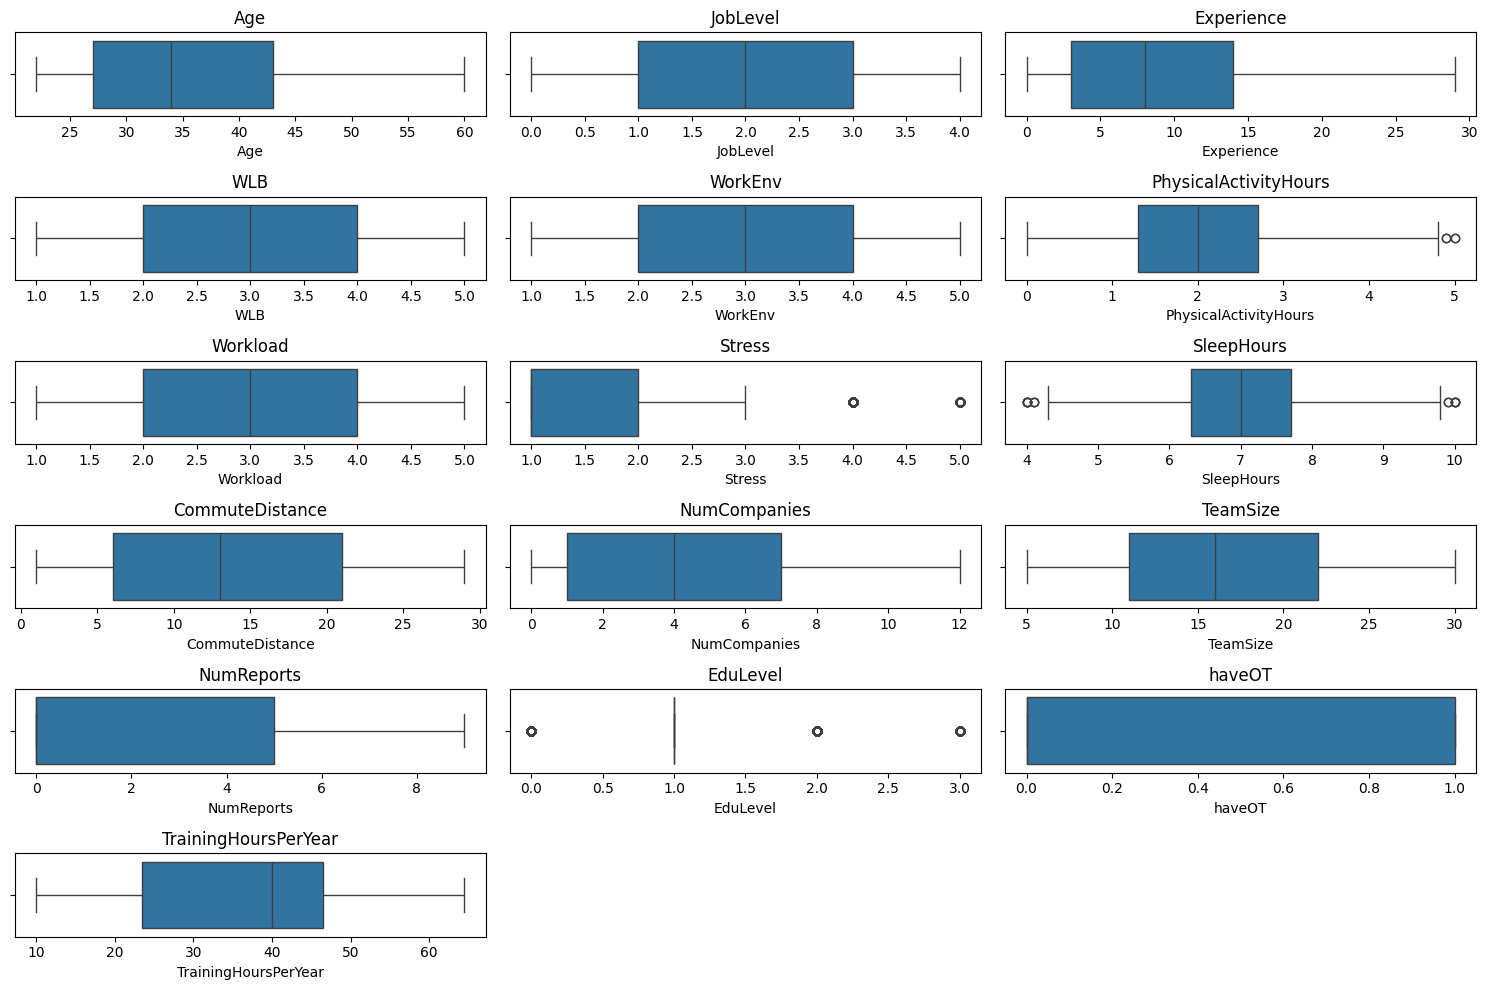

In [21]:
#Boxplot Visualization to look for points far from the box (outliers) and long whiskers that indicate possible skew:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols) // 3) + 1, 3, i + 1)
    sns.boxplot(x=X[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### The boxplot analysis shows that the majority of features do not contain substantial outliers. Continuous variables contain minor outliers, such as SleepHours and PhysicalActivityHours. These minor outliers were viewed as realistic and optionally handled using capping. Apparent outliers in variables like Stress and EduLevel were detected as artifacts of ordinal encoding rather than true anomalies, and therefore, no handling was applied.

In [22]:
# IQR Method (Quantitative Detection)
outlier_summary = {}

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

# Display results
print(outlier_summary)

{'Age': 0, 'JobLevel': 0, 'Experience': 0, 'WLB': 0, 'WorkEnv': 0, 'PhysicalActivityHours': 4, 'Workload': 0, 'Stress': 255, 'SleepHours': 14, 'CommuteDistance': 0, 'NumCompanies': 0, 'TeamSize': 0, 'NumReports': 0, 'EduLevel': 725, 'haveOT': 0, 'TrainingHoursPerYear': 0}


### I also performed outliers detection employing the IQR method to identify extreme values that can impact model performance. Features such as EduLevel and Stress were not handled because they stand for ordinal scales, and their detected outliers reflect natural data distribution rather than true anomalies. 
### As regards continuous features such as SleepHours and PhysicalActivityHours, mild capping (winsorization) was applied to restrict extreme values while maintaining all observations. This way guarantees data integrity and model robustness by putting together statistical methods with feature-specific context. 

In [23]:
# Capping:
cols_to_cap = ['SleepHours', 'PhysicalActivityHours']

for col in cols_to_cap:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X[col] = X[col].clip(lower, upper)

### **Multicollinearity (Correlation Matrix + Variance Inflation Factor (VIF)): A key concept for Logistic Regression**


#### Variance inflation factor (VIF) measures at which extent a feature is correlated with other features:

### **1. Correlation Matrix**

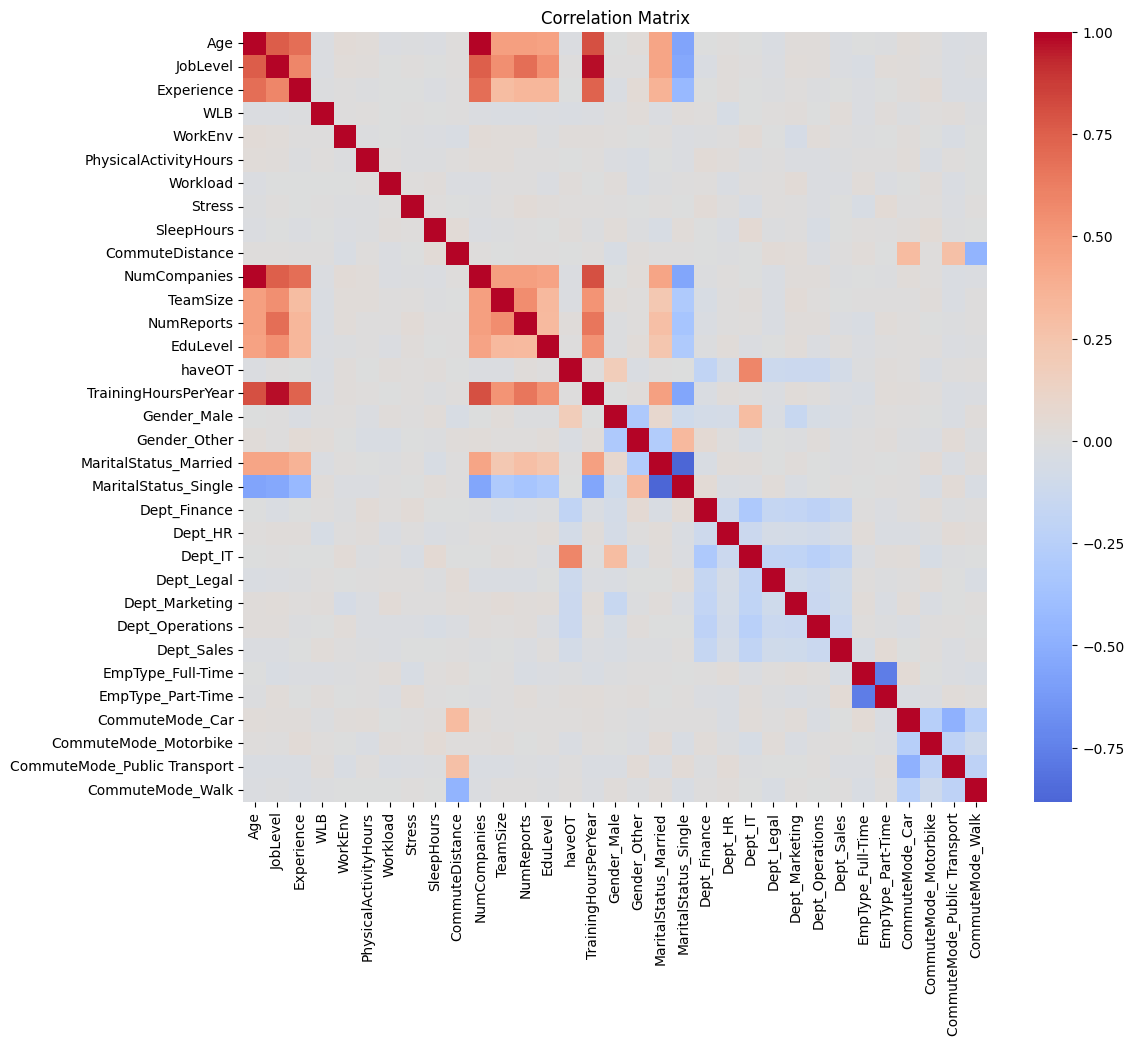

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title("Correlation Matrix")
plt.show()

### **Extract High Correlations:**

In [25]:
import numpy as np

# Compute correlation matrix
corr_matrix = X.corr()

# Select upper triangle (to avoid duplicates)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find correlations above threshold
high_corr = [(col, row, upper_triangle.loc[row, col]) 
             for col in upper_triangle.columns 
             for row in upper_triangle.index 
             if abs(upper_triangle.loc[row, col]) > 0.9]

# Display results
for pair in high_corr:
    print(f"{pair[0]} ↔ {pair[1]}: {pair[2]:.2f}")

NumCompanies ↔ Age: 1.00
TrainingHoursPerYear ↔ JobLevel: 0.98


In [26]:
print(corr_matrix.loc['NumCompanies', 'Age'])
print(corr_matrix.loc['TrainingHoursPerYear', 'JobLevel'])

0.9967673829323438
0.9773413306655101


### I identified highly correlated feature pairs using the correlation matrix, with a threshold above 0.9 to detect significant multicollinearity. Near-perfect correlations between Age and NumCompanies (r ≈ 0.997), and between TrainingHoursPerYear and JobLevel (r ≈ 0.977) were detected, suggesting redundancy. At this point, one feature can be almost linearly predicted from another
### To enhance model stability and interpretability, Age and TrainingHoursPerYear were dropped while keeping the more meaningful features (NumCompanies and JobLevel). I thus handled multicollinearity by removing highly correlated features, especially providing benefit to linear regression, such as Logistic Regression or Support Vector Machine.

In [27]:
X = X.drop(columns=['Age'])

In [28]:
X = X.drop(columns=['TrainingHoursPerYear'])

In [29]:
X.shape

(3025, 31)

### **2. Variance Inflation Factor (VIF):**

In [30]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Convert all columns to float
X_numeric = X.astype(float)

# Add constant
X_vif = sm.add_constant(X_numeric)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Remove constant
vif_data = vif_data[vif_data["Feature"] != "const"]

# Sort
vif_data = vif_data.sort_values(by="VIF", ascending=False)

In [31]:
from IPython.display import display, HTML

vif_text = vif_data.to_string(index=False)

display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:20px;
    border-radius:10px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.6;
    width:fit-content;
">

<h3 style="margin-top:0; color:#cfe3ff;">VIF (Multicollinearity Check)</h3>

<pre style="color:white; background-color:#0b2f6b; border:none;">
{vif_text}
</pre>

</div>
"""))

### I conducted Variance Inflation Factor (VIF) analysis to evaluate multicollinearity among the features. All variables displayed acceptable VIF values below 5 (critical threshold is 10), while two one-hot encoded categorical features, MaritalStatus_Single (VIF = 5.84) and Dept_IT (5.35), exhibited moderate multicollinearity. These values stay below the critical threshold and stand for dummy features resulting from the one-hot encoding. Therefore, I kept them. Briefly, the VIF results demonstrate that multicollinearity has been effectively handled and does not prompt a concern for model stability.

### **6. Features splitting, Checking class imbalance, and Scaling**


### Feature scaling is essential because Logistic Regression is distance-based. Features with large values dominate the model.

In [32]:
# Splitting data:
from sklearn.model_selection import train_test_split

y = df['JobSatisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Checking class imbalance on training set only, not full y:**

In [33]:
y_train.value_counts(normalize=True) * 100  # Test set must remain unseen. All decisions should be based on training data only. 

JobSatisfaction
4    41.280992
3    18.719008
5    17.066116
1    13.760331
2     9.173554
Name: proportion, dtype: float64

### The class distribution of the target variable revealed moderate imbalance, with JobSatisfaction level 4 representing the majority class (41%) and level 2 the minority (9%). To handle this, I included class weights in the Logistic Regression and Support Vector Machine models to ensure balanced learning across all classes.

In [34]:
# Creating the class_weight variable:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
# Create dictionary
class_weight_dict = dict(zip(classes, class_weights))

# Clean dictionary
class_weight_clean = {int(k): round(float(v), 2) for k, v in class_weight_dict.items()}

print(class_weight_clean)

{1: 1.45, 2: 2.18, 3: 1.07, 4: 0.48, 5: 1.17}


### I computed class weights based on the training data distribution, and I applied them to the Logistic Regression and Support Vector Machine models to handle the class imbalance. Handling class imbalance automatically assigns a higher weight to minority classes (1,2) and a lower weight to the majority class (4).

In [35]:
df_cleaned = pd.concat([X, y], axis=1)

In [36]:
print(df_cleaned.shape)

(3025, 32)


In [37]:
print(df_cleaned.head())

   JobLevel  Experience  WLB  WorkEnv  PhysicalActivityHours  Workload  \
0         2           7    1        1                    2.5         2   
1         2          12    1        1                    1.8         2   
2         0           1    2        4                    2.1         5   
3         1           6    2        2                    1.9         3   
4         1           1    3        1                    3.7         2   

   Stress  SleepHours  CommuteDistance  NumCompanies  ...  Dept_Marketing  \
0       1         7.6               20             3  ...           False   
1       2         7.9               15             4  ...           False   
2       4         6.5               17             0  ...            True   
3       1         7.5               13             2  ...           False   
4       1         4.9               20             0  ...           False   

   Dept_Operations  Dept_Sales  EmpType_Full-Time  EmpType_Part-Time  \
0            False  

In [38]:
#Convert All Booleans to Integers

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

### I converted Boolean variables to integer format (0/1) to ensure consistency across all features and compatibility with statistical methods such as VIF computation and feature scaling, which necessitate purely numeric inputs.

In [39]:
df_cleaned = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
print(df_cleaned.head())

   JobLevel  Experience  WLB  WorkEnv  PhysicalActivityHours  Workload  \
0         2           7    1        1                    2.5         2   
1         2          12    1        1                    1.8         2   
2         0           1    2        4                    2.1         5   
3         1           6    2        2                    1.9         3   
4         1           1    3        1                    3.7         2   

   Stress  SleepHours  CommuteDistance  NumCompanies  ...  Dept_Marketing  \
0       1         7.6               20             3  ...               0   
1       2         7.9               15             4  ...               0   
2       4         6.5               17             0  ...               1   
3       1         7.5               13             2  ...               0   
4       1         4.9               20             0  ...               0   

   Dept_Operations  Dept_Sales  EmpType_Full-Time  EmpType_Part-Time  \
0                0  

### The cleaned dataset (df_cleaned) consists of fully preprocessed features, including encoded categorical variables and transformed numerical variables, combined with the target variable (JobSatisfaction). I got all the features in a numeric format. The dataset is free of missing values or duplicates. Moreover, I handled features' multicollinearity and outliers through capping. The next step is to apply feature scaling for an effective Logistic Regression and Support Vector Machine modeling. 

In [40]:
df_cleaned.to_csv("employee_survey_cleaned.csv", index=False)

In [41]:
# Apply StandardScaler: Scaling and Saving the dataset:

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Initializing scaler
scaler = StandardScaler()

# Fitting on TRAIN only to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform test set
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (preserve column names & index)
X_train_scaled_df = pd.DataFrame(
    X_train_scaled, 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled, 
    columns=X_test.columns, 
    index=X_test.index
)

# Combine with the target variable Job Satisfaction
train_scaled_df = pd.concat([X_train_scaled_df, y_train], axis=1)
test_scaled_df = pd.concat([X_test_scaled_df, y_test], axis=1)

# Saving scaled data to CSV
X_train_scaled_df.to_csv("X_train_scaled.csv", index=False)
X_test_scaled_df.to_csv("X_test_scaled.csv", index=False)

train_scaled_df.to_csv("train_scaled_dataset.csv", index=False)
test_scaled_df.to_csv("test_scaled_dataset.csv", index=False)

print("Scaled training data:")
print(train_scaled_df.head())

print("\nScaled test data:")
print(test_scaled_df.head())

Scaled training data:
      JobLevel  Experience       WLB   WorkEnv  PhysicalActivityHours  \
201  -0.244759    0.695762  0.660754  1.395431              -0.744524   
211  -2.034232   -1.282454  0.660754 -1.418689               0.693013   
2838 -0.244759    0.130558 -0.030866 -0.715159               0.384970   
2206  0.649978    2.108773 -0.722486  0.691901               1.206420   
2756  0.649978   -0.293346 -0.030866 -1.418689              -0.231118   

      Workload    Stress  SleepHours  CommuteDistance  NumCompanies  ...  \
201   0.750737 -0.691936   -1.114132        -0.652038     -0.071842  ...   
211   0.750737 -0.691936   -0.408452         1.506228     -1.256570  ...   
2838  1.468832 -0.691936   -0.408452        -0.412231      0.224339  ...   
2206 -1.403551 -0.691936   -0.206830         1.506228      2.297612  ...   
2756  0.750737  2.150992   -0.206830         1.865939      0.520521  ...   

      Dept_Marketing  Dept_Operations  Dept_Sales  EmpType_Full-Time  \
201       

### I successfully standardized and saved features that resulted in values centered around zero with unit variance. I consistently applied the transformation to both training and test sets to avoid data leakage while preparing the data for Logistic Regression. 

## **Baseline Models**

### **1. Logistic Regression:**

In [42]:
#Train the model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_clean
)

log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{1: 1.45, 2: 2.18, 3: 1.07, 4: 0.48, ...}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a 

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML
import pandas as pd

# Make predictions
y_pred = log_reg.predict(X_test_scaled)

# Compute metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Small metrics table as text
metrics_text = f"""
Metric        Score
Accuracy      {acc:.4f}
Precision     {prec:.4f}
Recall        {rec:.4f}
F1-score      {f1:.4f}
"""

# Confusion matrix as text
cm_text = str(cm)

# Display styled output
display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:18px;
    border-radius:8px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.45;
    width:fit-content;
">

<h3 style="margin-top:0; color:#cfe3ff;">
Logistic Regression Model Evaluation
</h3>

<b style="color:#a9c9ff;">Overall Metrics:</b>
<pre style="color:white; background-color:#0b2f6b; border:none; margin-top:8px;">{metrics_text}</pre>

<b style="color:#a9c9ff;">Confusion Matrix:</b>
<pre style="color:white; background-color:#0b2f6b; border:none; margin-top:8px;">{cm_text}</pre>

<b style="color:#a9c9ff;">Classification Report:</b>
<pre style="color:white; background-color:#0b2f6b; border:none; margin-top:8px;">{report}</pre>

</div>
"""))

### The Logistic Regression model attained an overall accuracy of approximately 36%, suggesting limited predictive performance. While the model demonstrated reasonable performance for certain classes (e.g., JobSatisfaction = 1), it could not correctly classify others, especially the majority class (4) and minority class (2). 
### On the other hand, the confusion matrix exhibited substantial misclassification across adjacent classes, indicating overlapping class boundaries. As a result, I can note that linear modeling is insufficient to capture the complexity of the dataset. This motivates the use of more flexible non-linear models.

### **Visualization: Confusion matrix and Classification Report Heatmap:**

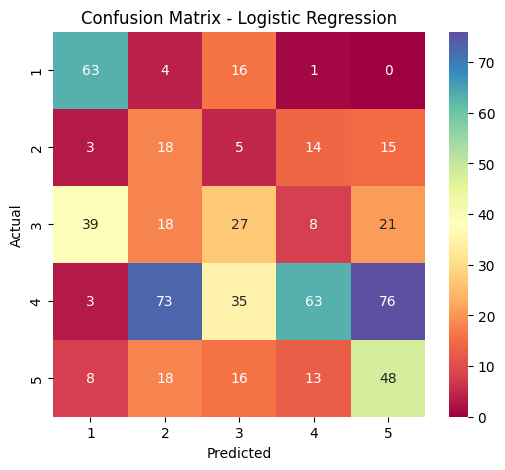

In [44]:
# Confusion matrix:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

labels = [1, 2, 3, 4, 5]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral',
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### The confusion matrix shows considerable misclassification across adjacent JobSatisfaction levels, especially for class 4, which is frequently predicted as classes 2 and 5. While class 1 is relatively well identified, the model could not properly distinguish between intermediate satisfaction levels, suggesting overlapping class boundaries. These results underscore the limitations of Logistic Regression in capturing non-linear relationships and incite the use of more flexible models.

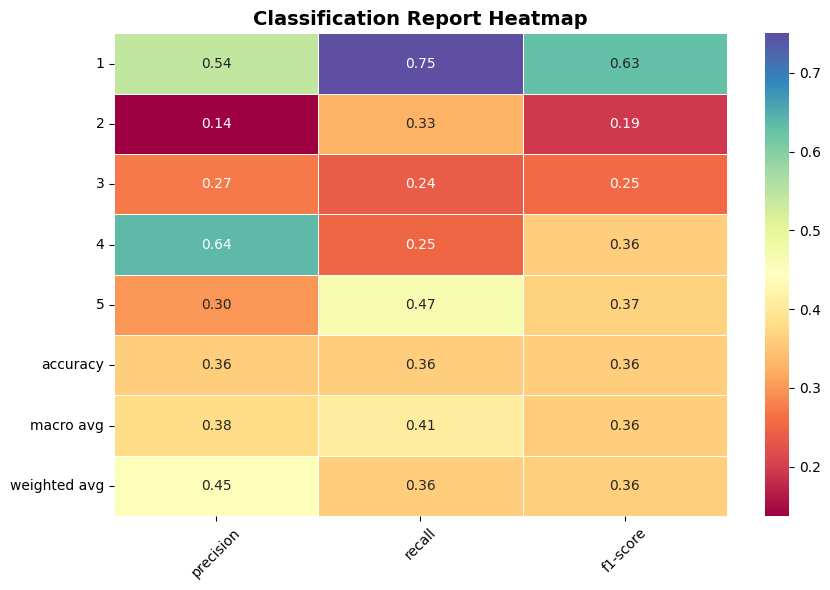

In [45]:
#Classification Report Heatmap:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Generate report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :].T

# Plot
plt.figure(figsize=(9, 6))

sns.heatmap(
    report_df,
    annot=True,
    fmt=".2f",
    cmap="Spectral",  
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

plt.title("Classification Report Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### The classification report heatmap demonstrates uneven model performance across classes. JobSatisfaction level 1 is well predicted. However, other classes, especially level 2, display low precision and F1-scores. 
### The model exhibits significant imbalance between precision and recall for certain classes (level 4), suggesting that many true instances are not correctly identified. Briefly, the results confirm that Logistic Regression struggles to capture the complexity and overlapping nature of the dataset, instigating the use of more flexible non-linear models.

In [46]:
# Cross-validation:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.33945419 0.32787801 0.35817576 0.32487353 0.32095039]
Mean CV F1: 0.33426637651067326


### Cross-validation results demonstrate consistent performance across folds, with a mean F1-score of approximately 0.33. The low variance among scores suggests that the model is stable and generalizes well to unseen data. Nonetheless, the overall performance remains limited. This confirms that Logistic Regression is not meaningfully expressive to capture the complexity of the dataset employee_survey.csv.

### **Identifying the most important feature in terms of absolute value of coefficients:**

In [47]:
import pandas as pd
import numpy as np

# Get coefficients
coefficients = log_reg.coef_

# Convert to DataFrame
coef_df = pd.DataFrame(
    coefficients,
    columns=X_train.columns
)

# Take mean absolute importance across classes
feature_importance = coef_df.abs().mean(axis=0)

# Sort
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

WorkEnv              0.518206
WLB                  0.432933
Workload             0.432306
Stress               0.348764
SleepHours           0.318960
haveOT               0.259350
EduLevel             0.145033
JobLevel             0.142809
EmpType_Part-Time    0.099092
Dept_Finance         0.095347
dtype: float64


### **Visualizing Logistic Relationship: Feature vs probability**

In [48]:
#Code (Binary-style visualization per class (class5))
# Define top_feature

import pandas as pd
import numpy as np

# Get coefficients
coefficients = log_reg.coef_

# Convert to DataFrame
coef_df = pd.DataFrame(
    coefficients,
    columns=X_train.columns
)

# Mean absolute importance across classes
feature_importance = coef_df.abs().mean(axis=0)

# Sort
feature_importance = feature_importance.sort_values(ascending=False)

# Get top feature
top_feature = feature_importance.index[0]

print("Most important feature:", top_feature)
plt.show()

Most important feature: WorkEnv


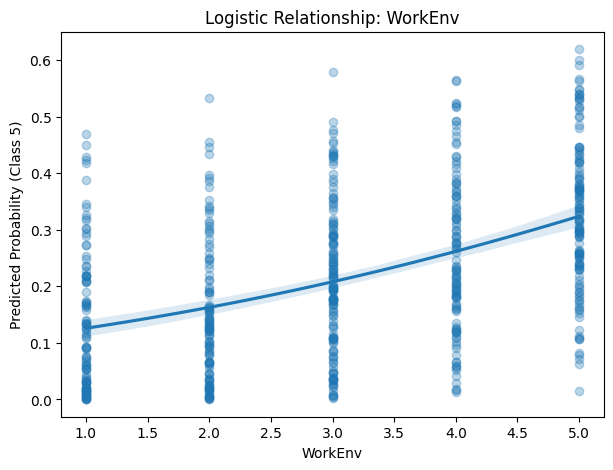

In [49]:
# Plot Relationship
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted probabilities for class 5
probs = log_reg.predict_proba(X_test_scaled)[:, 4]

# Extract feature values
feature_values = X_test[top_feature]

# Plot
plt.figure(figsize=(7, 5))

sns.regplot(
    x=feature_values,
    y=probs,
    logistic=True,
    scatter_kws={'alpha': 0.3}
)

plt.xlabel(top_feature)
plt.ylabel("Predicted Probability (Class 5)")
plt.title(f"Logistic Relationship: {top_feature}")

plt.show()

### The feature importance analysis revealed WorkEnv as the most influential variable in the Logistic Regression model. Visualization of its relationship with predicted probabilities demonstrates a clear positive trend, indicating that higher work environment ratings are linked to increased likelihood of higher job satisfaction. Nonetheless, the dispersion of points indicates that additional factors contribute to the prediction, underlining the complexity of the problem.

### **2. Decision Tree:**

In [50]:
# Train Decision Tree:

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight=class_weight_clean  # keeping consistency with imbalance handling
)

tree_model.fit(X_train, y_train)  # No scaling needed

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [51]:
# Predictions:
y_pred_tree = tree_model.predict(X_test)

In [52]:
# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from IPython.display import display, HTML

acc = accuracy_score(y_test, y_pred_tree)
prec = precision_score(y_test, y_pred_tree, average='weighted')
rec = recall_score(y_test, y_pred_tree, average='weighted')
f1 = f1_score(y_test, y_pred_tree, average='weighted')

cm = confusion_matrix(y_test, y_pred_tree)
report = classification_report(y_test, y_pred_tree)

# Format text
metrics_text = f"""
Metric        Score
Accuracy      {acc:.4f}
Precision     {prec:.4f}
Recall        {rec:.4f}
F1-score      {f1:.4f}
"""

cm_text = str(cm)

# Display styled output
display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:18px;
    border-radius:8px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.5;
    width:fit-content;
">

<h3 style="margin-top:0;">Decision Tree Model Evaluation</h3>

<b>Overall Metrics:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{metrics_text}</pre>

<b>Confusion Matrix:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{cm_text}</pre>

<b>Classification Report:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{report}</pre>

</div>
"""))

### The Decision Tree model correctly identifies more than half of class 4 cases. Indeed, Decision Tree captures non-linear patterns, which enhances performance, but still struggles with overlapping classes. The model improved overall performance compared to Logistic Regression, attaining higher accuracy and F1-score. 
### Noticeably, it substantially improved recall for the majority class (JobSatisfaction = 4), demonstrating better capture of non-linear relationships. Nonetheless, performance remains limited for minority and intermediate classes, indicating persistent class overlap. These results confirm that while Decision Trees offered improved flexibility, further model refinement is needed.

In [53]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores_tree = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV F1 Scores:", cv_scores_tree)
print("Mean CV F1:", cv_scores_tree.mean())

CV F1 Scores: [0.33532241 0.36501748 0.38287684 0.36321761 0.36568837]
Mean CV F1: 0.3624245409886004


### Cross-validation results for the Decision Tree model demonstrate stable performance across folds, with a mean F1-score of approximately 0.36. This indicates an improvement over Logistic Regression while maintaining good generalization. The model displays a close alignment between cross-validation and test performance.

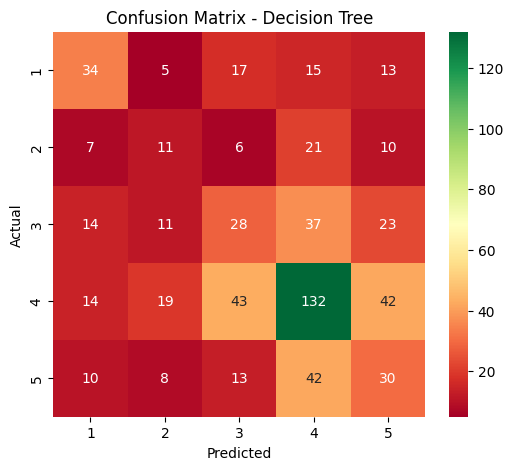

In [54]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(y_test, y_pred_tree)

labels = [1, 2, 3, 4, 5]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Decision Tree decreases underfitting (seen in Logistic Regression), but holds a tendency to bias predictions toward the majority class. The confusion matrix depicts a significant improvement in correctly classifying the majority class (JobSatisfaction = 4), with a considerable increase in true positives. However, the model displays a tendency to misclassify neighboring classes (particularly levels 3 and 5) as class 4, suggesting bias toward the dominant class. Decision Tree captures non-linear relationships more effectively than Logistic Regression. However, challenges related to class overlap and imbalance remain.

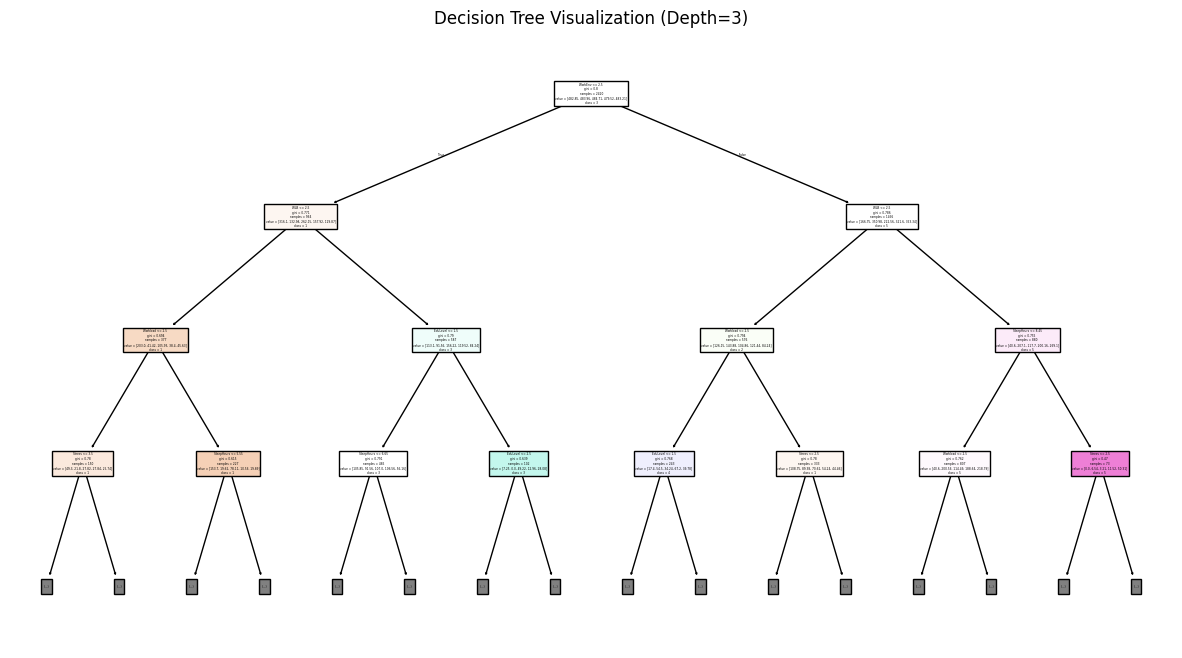

In [55]:
#Tree visualization:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=[str(i) for i in [1,2,3,4,5]],
    filled=True,
    max_depth=3  # limit for readability
)

plt.title("Decision Tree Visualization (Depth=3)")
plt.show()

### The model uses hierarchical decision rules, combining multiple features to predict job satisfaction. The model confirms the presence of non-linear relationships and interaction between variables in the dataset, providing greater interpretability compared to logistic regression.

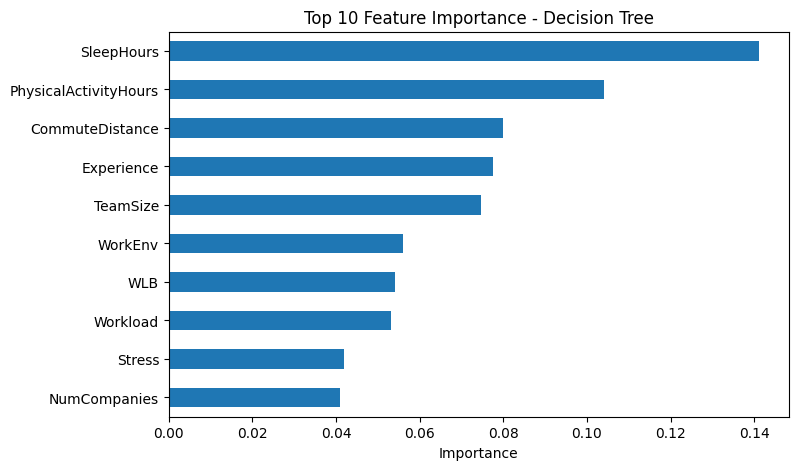

In [56]:
# Feature importance visualization:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = tree_model.feature_importances_
feature_names = X_train.columns

# Create DataFrame
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(8, 5))
feat_imp.head(10).plot(kind='barh')
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.show()

### Employee well-being factors (sleep and physical activity) play a more noticeable role in job satisfaction than traditional workplace factors when non-linear relationships are integrated.
### On the other hand, feature importance analysis from the Decision Tree model shows SleepHours as the most influential predictor of job satisfaction, followed by physical activity and commute-related factors. However, the Logistic Regression model depicts the work environment as the most important feature. 
### The difference indicates the presence of non-linear relationships and interactions between variables, which are better captured by the Decision Tree. In a nutshell, both personal well-being and workplace conditions contribute to job satisfaction, although their relative importance depends on the modeling approach.

### **3. Support Vector Machine:**

#### It is worth underlining that the Support Vector Model handles complex boundaries, works well wiht scaled data and frequently improves performance. The SVM baseline is modeled using default parameters, scaled data, and class weights.

In [57]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',  # default nonlinear kernel
    class_weight=class_weight_clean,
    probability= True,  # needed for probability outputs
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.","{1: 1.45, 2: 2.18, 3: 1.07, 4: 0.48, ...}"
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Since the dataset is relatively small and training time is minimal, I enabled probability estimation in the SVM model to allow for a more detailed analysis of prediction confidence.

In [58]:
# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

In [59]:

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from IPython.display import display, HTML

acc = accuracy_score(y_test, y_pred_svm)
prec = precision_score(y_test, y_pred_svm, average='weighted')
rec = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

cm = confusion_matrix(y_test, y_pred_svm)
report = classification_report(y_test, y_pred_svm)

# Format text
metrics_text = f"""
Metric        Score
Accuracy      {acc:.4f}
Precision     {prec:.4f}
Recall        {rec:.4f}
F1-score      {f1:.4f}
"""

cm_text = str(cm)

# Styled display
display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:18px;
    border-radius:8px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.5;
    width:fit-content;
">

<h3 style="margin-top:0;">SVM Model Evaluation</h3>

<b>Overall Metrics:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{metrics_text}</pre>

<b>Confusion Matrix:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{cm_text}</pre>

<b>Classification Report:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{report}</pre>

</div>
"""))

### The SVM model achieves moderate performance, with an accuracy of 40% and an F1-score of 0.41. It performs best on class 4, which is also the most frequently predicted class, suggesting a bias toward this category. While class 1 is detected reasonably well, the model struggles significantly with classes 2 and 3, showing low precision and recall. The confusion matrix reveals substantial overlap between neighboring classes, indicating that the model has difficulty distinguishing between similar satisfaction levels.

In [60]:
#Confidence Analysis:
probs = svm_model.predict_proba(X_test_scaled)
probs

array([[0.03383059, 0.0890282 , 0.08445022, 0.56401098, 0.22868001],
       [0.00164874, 0.08438085, 0.04055282, 0.62879816, 0.24461943],
       [0.05502711, 0.16072827, 0.17412542, 0.44856078, 0.16155842],
       ...,
       [0.29001524, 0.0989728 , 0.34686732, 0.11679557, 0.14734906],
       [0.52869916, 0.06532572, 0.30860655, 0.05764802, 0.03972056],
       [0.03717809, 0.13619286, 0.10147166, 0.58046372, 0.14469366]],
      shape=(605, 5))

### Each row in the output represents one employee, and each value shows the probability of that employee belonging to a specific satisfaction level.
### Confidence is measured as the highest predicted probability for each sample. A higher value indicates that the model is more certain about its prediction, while lower values suggest uncertainty, especially when probabilities are similar across multiple classes.
### The SVM model depicts moderate confidence in its predictions, with many results leaning toward class 4. Nonthless, in several cases, the probabilities are quite close across multiple classes, indicating some uncertainty and overlap between satisfaction levels.

In [61]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores_svm = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV F1 Scores:", cv_scores_svm)
print("Mean CV F1:", cv_scores_svm.mean())

CV F1 Scores: [0.41304549 0.38205041 0.40574824 0.38096914 0.38239476]
Mean CV F1: 0.39284160971734366


### The SVM model achieved a mean cross-validation F1-score of 0.39, with consistent performance across all folds. The similarity between cross-validation and test results indicates that the model generalizes well and is not overfitting. Nonetheless, the overall performance remains moderate, indicating that the classification task is challenging due to the overlap between classes.

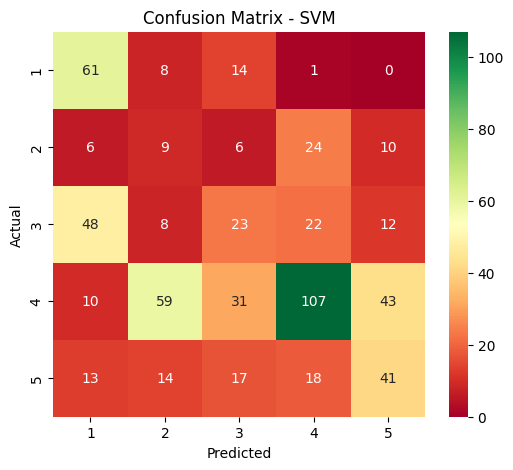

In [62]:
# Confusion Matrix (Recommended)
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

labels = [1, 2, 3, 4, 5]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

### The confusion matrix shows that the model performs best on class 4, which has the highest number of correct predictions. However, there is significant misclassification across neighboring classes, especially between classes 2, 3, 4, and 5. Class 2 is especially poorly predicted, with most instances being misclassified as having higher satisfaction levels. It is worth highlighting that misclassification is identified when the predicted class differs from the actual class, and it can be analyzed using direct comparison or through the off-diagonal values in the confusion matrix.
### Briefly, the results show substantial overlap between classes, making it difficult for the model to clearly distinguish between different satisfaction levels. Class overlapping is present when different classes have similar feature patterns, and then the model is not able to clearly separate them. 

In [63]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Ignore undefined metric warnings (precision/recall issues)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Ignore SVM feature name warning
warnings.filterwarnings("ignore", message=".*X has feature names.*")

# Ignore XGBoost label encoder warning
warnings.filterwarnings("ignore", message=".*use_label_encoder.*")

# Ignore Logistic Regression FutureWarning (GridSearch)
warnings.filterwarnings("ignore", category=FutureWarning)

### **Visualization of confidence prediction:**

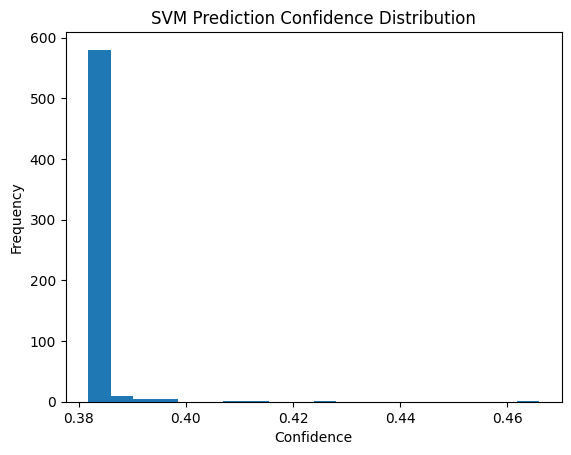

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Getting probabilites:
probs = svm_model.predict_proba(X_test)

# Convert to DataFrame
probs_df = pd.DataFrame(probs, columns=[1, 2, 3, 4, 5])
import matplotlib.pyplot as plt

confidence = probs_df.max(axis=1)

plt.hist(confidence, bins=20)
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("SVM Prediction Confidence Distribution")
plt.show()

### Most predictions fall in a narrow range around 0.38 to 0.40, showing that the model is not very confident. This indicates that the classes overlap and are hard to separate, which explains the moderate performance and frequent misclassification between similar classes.

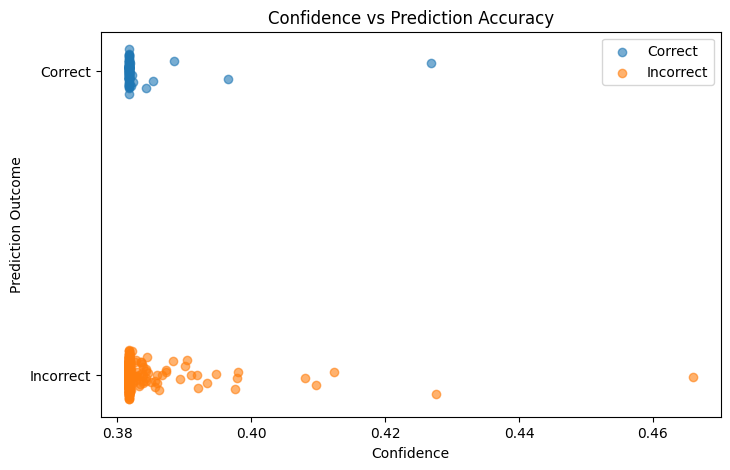

In [65]:
# Confidence vs Correctness:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

y_pred_svm = svm_model.predict(X_test)
probs = svm_model.predict_proba(X_test)

actual = np.array(y_test)
predicted = np.array(y_pred_svm)
confidence = probs.max(axis=1)

comparison = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted,
    "Confidence": confidence
})

comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

# jitter for visualization
y_vals = comparison["Correct"].astype(int).astype(float)
jitter = np.random.normal(0, 0.03, size=len(comparison))

correct = comparison[comparison["Correct"]]
incorrect = comparison[~comparison["Correct"]]

plt.figure(figsize=(8,5))
plt.scatter(correct["Confidence"], 1 + jitter[comparison["Correct"]],
            alpha=0.6, label="Correct")
plt.scatter(incorrect["Confidence"], 0 + jitter[~comparison["Correct"]],
            alpha=0.6, label="Incorrect")

plt.xlabel("Confidence")
plt.ylabel("Prediction Outcome")
plt.yticks([0, 1], ["Incorrect", "Correct"])
plt.title("Confidence vs Prediction Accuracy")
plt.legend()
plt.show()

### The confidence vs accuracy plot shows that both correct and incorrect predictions are concentrated within a narrow confidence range. There is significant overlap between the two groups, indicating that higher confidence does not consistently correspond to correct predictions. In some cases, the model is even highly confident in incorrect predictions. This suggests that the model is not well-calibrated and struggles to clearly distinguish between classes.

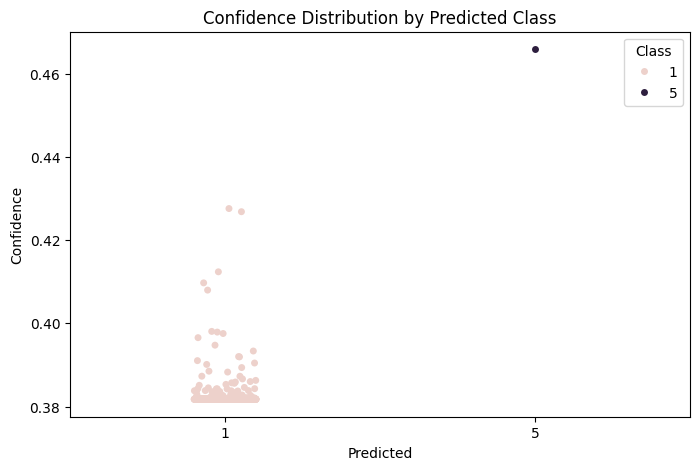

In [66]:
#Class-wise Confidence Boxplot shows how confident the model is per class

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.stripplot(
    x="Predicted",
    y="Confidence",
    data=comparison,
    hue="Predicted",   
    jitter=True
)

plt.title("Confidence Distribution by Predicted Class")
plt.legend(title="Class")
plt.show()

### The confidence distribution by predicted class shows that the model mainly predicts a limited number of classes, with most predictions concentrated in class 1 and a few in class 5. Confidence values remain low and tightly clustered across these predictions, indicating that the model does not strongly differentiate between classes. Even for the highest-confidence predictions, the values remain below 0.5, suggesting overall uncertainty and weak class separation.

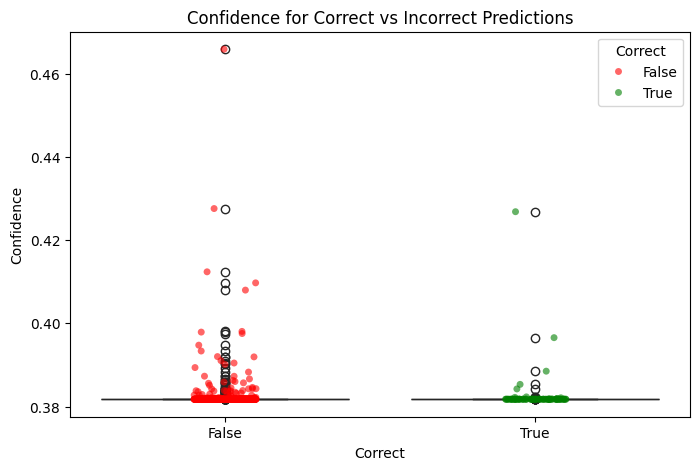

In [67]:
# Misclassification Visualization compares confidence of correct vs wrong predictions
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Correct",
    y="Confidence",
    data=comparison,
    hue="Correct",
    palette={True: "green", False: "red"},
    legend=False
)

sns.stripplot(
    x="Correct",
    y="Confidence",
    data=comparison,
    hue="Correct",
    palette={True: "green", False: "red"},
    jitter=True,
    alpha=0.6
)

plt.title("Confidence for Correct vs Incorrect Predictions")
plt.show()

### The plot shows that confidence values for both correct and incorrect predictions are very similar, with most values clustered around 0.38 to 0.39. There is no clear separation between the two groups, indicating that higher confidence does not necessarily correspond to correct predictions. In some cases, the model even makes incorrect predictions with relatively higher confidence. In a nutshell, this suggests that the model is not well-calibrated and struggles to distinguish between classes.

### **4. Baseline models comparison:**

In [68]:
# Creating Comparison Table:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

# 1. Logistic Regression
y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log, average="weighted")
cv_scores_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring="f1_weighted")
cv_log = cv_scores_log.mean()

# 2. Decision Tree
y_pred_tree = tree_model.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree, average="weighted")
cv_scores_tree = cross_val_score(tree_model, X_train, y_train, cv=5, scoring="f1_weighted")
cv_tree = cv_scores_tree.mean()

# 3. Support Vector Machine
y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average="weighted")
cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring="f1_weighted")
cv_svm = cv_scores_svm.mean()

# 4. Comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM"],
    "Accuracy": [acc_log, acc_tree, acc_svm],
    "F1 Score": [f1_log, f1_tree, f1_svm],
    "CV F1 Mean": [cv_log, cv_tree, cv_svm]
})
print(results)

                 Model  Accuracy  F1 Score  CV F1 Mean
0  Logistic Regression  0.361983  0.363972    0.334266
1        Decision Tree  0.388430  0.389534    0.362425
2                  SVM  0.398347  0.405458    0.392842


### Among the baseline models, SVM achieved the best overall performance, with the highest accuracy, weighted F1-score, and cross-validation F1-score. Decision Tree performed slightly better than Logistic Regression, but both models remained below SVM. These results suggest that the classification problem is not purely linear and that SVM is better able to capture the underlying structure of the data. 
### However, the overall performance of all three models is still moderate, which supports the earlier finding that the classes overlap and are difficult to separate clearly.

### **Visualization: Bar Chart and Focused F1 comparision**

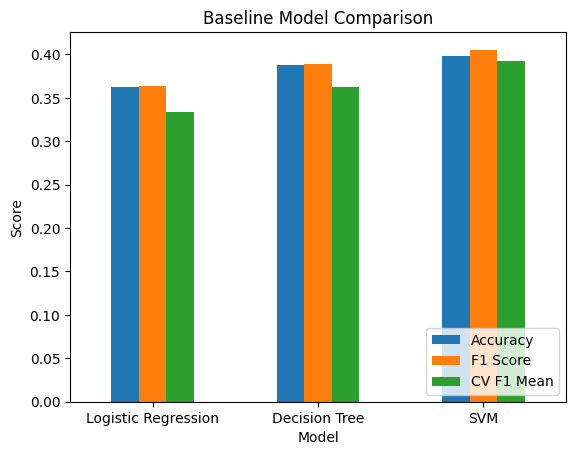

In [69]:
#Bar Chart:
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy", "F1 Score", "CV F1 Mean"]].plot(kind="bar")

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

### The bar chart shows that SVM consistently achieves the highest scores across all evaluation metrics, followed by Decision Tree and Logistic Regression. The differences are not large, but SVM demonstrates a clear advantage in both test and cross-validation performance.

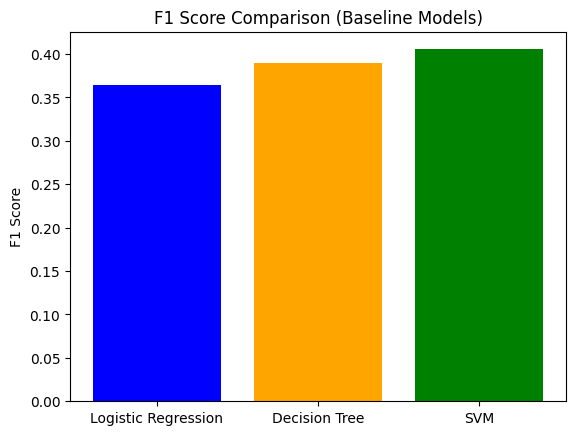

In [70]:
#Focused F1 Comparison: 
plt.bar(
    results["Model"],
    results["F1 Score"],
    color=["blue", "orange", "green"]
)

plt.title("F1 Score Comparison (Baseline Models)")
plt.ylabel("F1 Score")
plt.show()

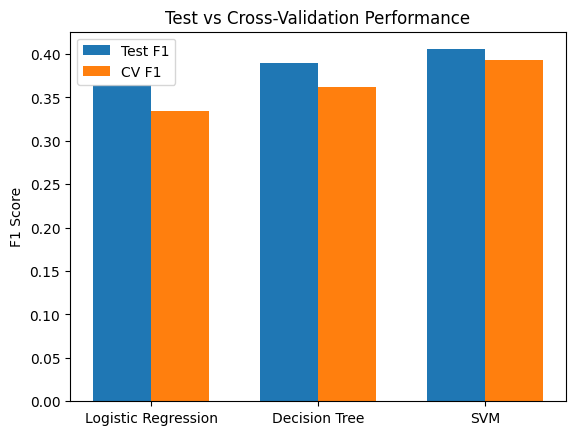

In [71]:
#CV vs Test Comparison:
import numpy as np

x = np.arange(len(results["Model"]))
width = 0.35

plt.bar(x - width/2, results["F1 Score"], width, label="Test F1")
plt.bar(x + width/2, results["CV F1 Mean"], width, label="CV F1")

plt.xticks(x, results["Model"])
plt.title("Test vs Cross-Validation Performance")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

### The visual comparison shows that SVM performs slightly better than the other baseline models across all metrics. Although the differences are not very large, SVM has the highest F1-score and more consistent results between the test set and cross-validation. The Decision Tree performs reasonably well but appears less stable, while Logistic Regression has the lowest performance overall. Overall, the results suggest that the problem is quite challenging, as all models only achieve moderate performance, likely due to overlap between the classes.

## **Advanced Models**

### **1. Random Forest:**

In [72]:
# Train and evaluate Random Forest:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from IPython.display import display, HTML
from sklearn.model_selection import cross_val_score

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

cv_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
).mean()

cm = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, zero_division=0)

# Format text
metrics_text = f"""
Metric        Score
Accuracy      {acc:.4f}
Precision     {prec:.4f}
Recall        {rec:.4f}
F1-score      {f1:.4f}
"""

cm_text = str(cm)

# Styled display
display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:18px;
    border-radius:8px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.5;
    width:fit-content;
">

<h3 style="margin-top:0;">Random Forest Model Evaluation</h3>

<b>Overall Metrics:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{metrics_text}</pre>

<b>Confusion Matrix:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{cm_text}</pre>

<b>Classification Report:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{report}</pre>

</div>
"""))

### The Random Forest model improves overall performance compared to the baseline models, achieving higher accuracy and F1-score. However, the results reveal a strong bias toward class 4, which dominates the predictions. Notably, class 2 is not predicted at all, indicating that the model struggles to identify minority or overlapping classes. While Random Forest captures more complex patterns than the baseline models, the underlying issue of class overlap and imbalance persists, limiting its effectiveness across all classes. Briefly, Random Forest performs better than the baseline models, but it sacrifices class balance for higher accuracy. 

In [73]:
# Add Random Forest to comparison table:
results_advanced = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Random Forest"],
    "Accuracy": [acc_log, acc_tree, acc_svm, acc_rf],
    "F1 Score": [f1_log, f1_tree, f1_svm, f1_rf],
    "CV F1 Mean": [cv_log, cv_tree, cv_svm, cv_rf]
})

print(results_advanced)

                 Model  Accuracy  F1 Score  CV F1 Mean
0  Logistic Regression  0.361983  0.363972    0.334266
1        Decision Tree  0.388430  0.389534    0.362425
2                  SVM  0.398347  0.405458    0.392842
3        Random Forest  0.507438  0.425869    0.414537


### The comparison of all models shows a clear improvement in performance as model complexity increases. Logistic Regression performs the worst, followed by Decision Tree and SVM. Random Forest achieves the best overall performance, with the highest accuracy, F1-score, and cross-validation score, indicating better generalization. However, despite this improvement, the overall performance remains moderate, suggesting that the classification task is challenging due to overlapping class boundaries and difficulty in distinguishing between similar satisfaction levels.

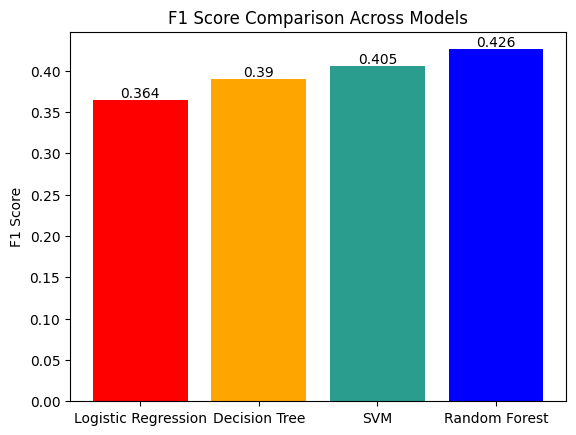

In [74]:
# Visualize the updated comparison: 
import matplotlib.pyplot as plt

colors = ["red", "orange", "#2a9d8f", "blue"]

bars = plt.bar(results_advanced["Model"], results_advanced["F1 Score"], color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval, 3), ha='center', va='bottom')

plt.title("F1 Score Comparison Across Models")
plt.ylabel("F1 Score")
plt.show()

### The chart shows a clear improvement in performance across models, with Logistic Regression performing the weakest, followed by Decision Tree and SVM. Random Forest achieves the highest F1-score, making it the best-performing model. Although the improvement is consistent, the differences are relatively small, suggesting that the problem remains challenging despite using more advanced models.

### It is worth underlining that the ensemble method Random Forest achieves the best overall performance among all models, benefiting from its ability to capture complex, non-linear relationships and reduce overfitting through ensemble learning. However, despite this improvement, the model shows a strong bias toward the dominant class and struggles to correctly predict minority classes, particularly class 2. This indicates that while Random Forest improves accuracy and overall F1-score, it does not fully address the underlying issue of class imbalance and overlap. The close alignment between cross-validation and test performance suggests that the model is stable and generalizes well.

### **Random Forest Confusion Matrix**

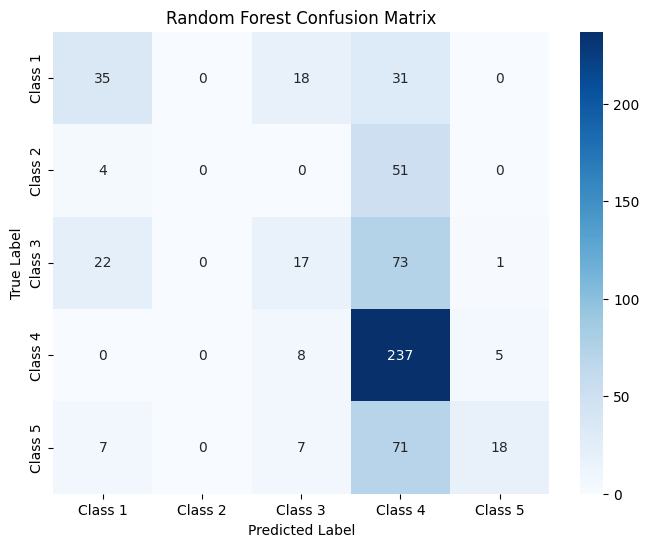

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
class_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### The confusion matrix indicates that the Random Forest model achieves strong performance for the dominant Class 4, as reflected by the high number of correct classifications, but exhibits poor predictive ability for minority classes such as Class 2 and Class 5, highlighting class imbalance and reduced model generalization across all categories.

### **Decision Tree overfitting vs Random Forest overfitting visualization:**


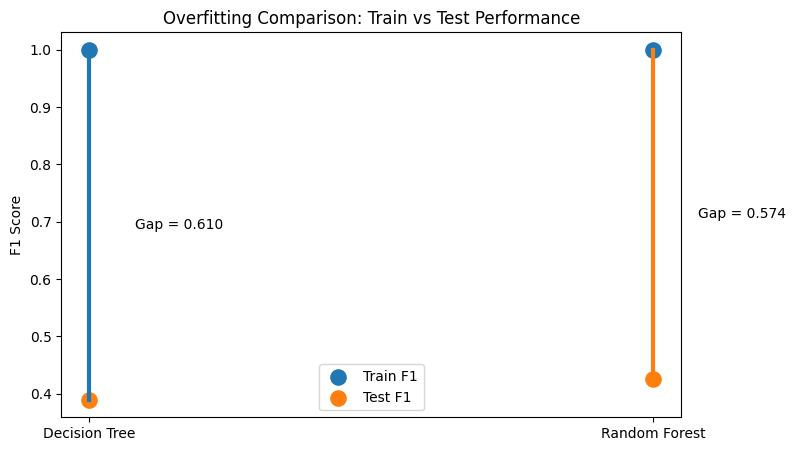

In [76]:
# Train vs Test Performance:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# 1. Compute Train/Test F1

# Decision Tree
y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

f1_train_tree = f1_score(y_train, y_train_pred_tree, average="weighted")
f1_test_tree = f1_score(y_test, y_test_pred_tree, average="weighted")

# Random Forest
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

f1_train_rf = f1_score(y_train, y_train_pred_rf, average="weighted")
f1_test_rf = f1_score(y_test, y_test_pred_rf, average="weighted")

# 2. Prepare Data

models = ["Decision Tree", "Random Forest"]
train_scores = [f1_train_tree, f1_train_rf]
test_scores = [f1_test_tree, f1_test_rf]

x = np.arange(len(models))

# 3. Plot

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(x, train_scores, s=120, label="Train F1")
plt.scatter(x, test_scores, s=120, label="Test F1")

# Lines + Gap Labels
for i in range(len(models)):
    # Draw vertical line
    plt.plot([x[i], x[i]], [test_scores[i], train_scores[i]], linewidth=3)

    # Compute gap
    gap = train_scores[i] - test_scores[i]

    # Place text slightly to the right (no overlap)
    plt.text(
        x[i] + 0.08,
        test_scores[i] + gap / 2,
        f"Gap = {gap:.3f}",
        va="center",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

# Labels and title
plt.xticks(x, models)
plt.ylabel("F1 Score")
plt.title("Overfitting Comparison: Train vs Test Performance")
plt.legend()

plt.show()

### The Decision Tree clearly overfits, as it performs perfectly on training data but poorly on test data. Random Forest reduces this effect, as shown by the smaller gap, but it still shows some overfitting.

## **2. XGBoost**

### XGBoost expects class labels starting at 0 for multiclass classification. Because the target classes are 1 to 5, I needed to make them 0 to 4.

In [77]:
#Encoding target labels for XGBoost
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

In [78]:
y_train_xgb = y_train.to_numpy().ravel() - 1
y_test_xgb = y_test.to_numpy().ravel() - 1

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train_xgb)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from IPython.display import display, HTML

acc = accuracy_score(y_test_xgb, y_pred_xgb)
prec = precision_score(y_test_xgb, y_pred_xgb, average='weighted')
rec = recall_score(y_test_xgb, y_pred_xgb, average='weighted')
f1 = f1_score(y_test_xgb, y_pred_xgb, average='weighted')

cm = confusion_matrix(y_test_xgb, y_pred_xgb)
report = classification_report(y_test_xgb, y_pred_xgb)

# Format text (same style)
metrics_text = f"""
Metric        Score
Accuracy      {acc:.4f}
Precision     {prec:.4f}
Recall        {rec:.4f}
F1-score      {f1:.4f}
"""

cm_text = str(cm)

# Styled display (same as your RF)
display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:18px;
    border-radius:8px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.5;
    width:fit-content;
">

<h2 style="margin-top:0;">XGBoost Model Evaluation</h2>

<b>Overall Metrics:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{metrics_text}</pre>

<b>Confusion Matrix:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{cm_text}</pre>

<b>Classification Report:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{report}</pre>

</div>
"""))

### The initial XGBoost model was trained on the original imbalanced dataset and achieved an accuracy of approximately 50%. However, the classification report reveals a strong bias toward the majority class (Class 3 [4]), which achieved a high recall of 0.79. In contrast, minority classes, particularly Class 1 [2], were poorly predicted, with a recall as low as 0.04. This indicates that the model is heavily influenced by the class distribution and struggles to generalize across underrepresented classes. These results highlight the need for resampling techniques such as SMOTE to improve class balance and model fairness.

In [79]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Convert labels from 1–5 to 0–4 for XGBoost
y_train_xgb = y_train.to_numpy().ravel() - 1
y_test_xgb = y_test.to_numpy().ravel() - 1

# Cross-validation for XGBoost
cv_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train_xgb,
    cv=5,
    scoring='f1_weighted'
).mean()

# Train XGBoost again using corrected labels
xgb_model.fit(X_train, y_train_xgb)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
acc_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, average='weighted')

# Comparison table
results_advanced = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Random Forest", "XGBoost"],
    "Accuracy": [acc_log, acc_tree, acc_svm, acc_rf, acc_xgb],
    "F1 Score": [f1_log, f1_tree, f1_svm, f1_rf, f1_xgb],
    "CV F1 Mean": [cv_log, cv_tree, cv_svm, cv_rf, cv_xgb]
})

print(results_advanced)

                 Model  Accuracy  F1 Score  CV F1 Mean
0  Logistic Regression  0.361983  0.363972    0.334266
1        Decision Tree  0.388430  0.389534    0.362425
2                  SVM  0.398347  0.405458    0.392842
3        Random Forest  0.507438  0.425869    0.414537
4              XGBoost  0.492562  0.454120    0.454375


### The XGBoost model achieves moderate but stable performance, with an accuracy of 0.49 and an F1-score of 0.46, which is consistent with the cross-validation F1 of 0.45, indicating good generalization.
### However, the results reveal a strong imbalance in class predictions. In particular, class 3 [4] dominates the model’s performance, achieving the highest recall of 0.79 and an F1-score of 0.66, indicating that most of its instances are correctly identified. This is further supported by the confusion matrix, where 198 out of 250 class 3 [4] samples are correctly classified.
### In contrast, minority classes perform poorly. For example, class 1 [2] has an extremely low recall of 0.04, with only 2 out of 55 instances correctly predicted, while most are misclassified as class 3 [4]. Similarly, class 2 [3] shows weak performance (F1 = 0.26), with a large portion of its samples (48 instances) also predicted as class 3 [4]. Class 4 [5] suffers from low recall (0.26), indicating that many of its instances are missed despite reasonable precision.
### Overall, these results suggest that while the model is stable and performs well on the dominant class, it struggles to distinguish minority classes, leading to a bias toward predicting class 3 [4]. [Note: It is worth remembering at this point that XGBoost model counts classes from 0 (instead of 1) to 4, while other models count classes from 1 to 5].

In [80]:
# Converting XGBoost Predictions Back to Original Classes (1–5)
y_pred_xgb_original = le.inverse_transform(y_pred_xgb)

In [81]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Convert labels from 1–5 to 0–4 for XGBoost
y_train_xgb = y_train.to_numpy().ravel() - 1
y_test_xgb = y_test.to_numpy().ravel() - 1

# Cross-validation for XGBoost
cv_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train_xgb,
    cv=5,
    scoring='f1_weighted'
).mean()

# Train XGBoost again using corrected labels
xgb_model.fit(X_train, y_train_xgb)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
acc_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, average='weighted')

# Comparison table
results_advanced = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Random Forest", "XGBoost"],
    "Accuracy": [acc_log, acc_tree, acc_svm, acc_rf, acc_xgb],
    "F1 Score": [f1_log, f1_tree, f1_svm, f1_rf, f1_xgb],
    "CV F1 Mean": [cv_log, cv_tree, cv_svm, cv_rf, cv_xgb]
})

print(results_advanced)

                 Model  Accuracy  F1 Score  CV F1 Mean
0  Logistic Regression  0.361983  0.363972    0.334266
1        Decision Tree  0.388430  0.389534    0.362425
2                  SVM  0.398347  0.405458    0.392842
3        Random Forest  0.507438  0.425869    0.414537
4              XGBoost  0.492562  0.454120    0.454375


### The comparison of models shows a clear progression in performance from simpler to more advanced methods. Logistic Regression performs the weakest, with an accuracy of 0.36 and F1-score of 0.36, indicating limited ability to capture complex patterns. Decision Tree and SVM offer slight improvements, with SVM achieving a higher F1-score of 0.41 and more consistent cross-validation performance (CV F1 = 0.39). 
### Ensemble methods, however, deliver the strongest results. Random Forest achieves the highest accuracy (0.51), but its F1-score (0.43) is lower than XGBoost, suggesting it is less effective at balancing class predictions. In contrast, XGBoost provides the best overall balance, with the highest F1-score of 0.45 and the strongest cross-validation performance (CV F1 = 0.45), indicating both improved class-wise performance and model stability. Although its accuracy (0.49) is slightly lower than Random Forest, the higher F1-score suggests that XGBoost handles class imbalance more effectively. 
### Briefly, these results demonstrate that XGBoost is the most reliable model in this comparison, particularly when considering both performance and generalization.

### **XGBoost visualization - Confusion matrix to check whether it fixes the class 2 problem and whether predictions are still biased toward class 4:**

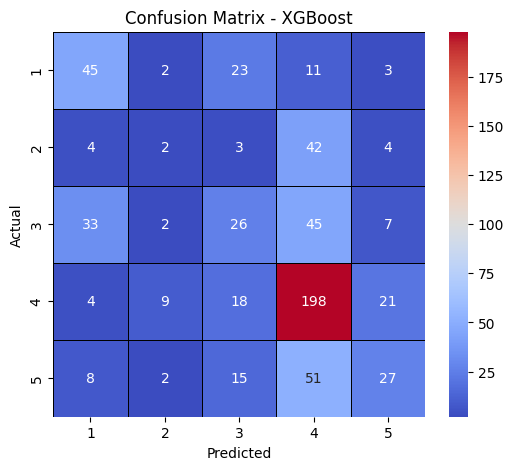

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb, labels=[0,1,2,3,4])

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="black",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

### The confusion matrix shows that XGBoost improves prediction performance for several classes compared to previous models, particularly for classes 1  and 3. However, class 4 remains dominant, with many samples from other classes being misclassified as class 4. Class 2 continues to perform poorly, indicating difficulty in distinguishing it from neighboring classes. Overall, while XGBoost provides better balance and improved F1-score, misclassification between adjacent classes remains a key challenge, suggesting that the underlying class boundaries are not clearly separable.

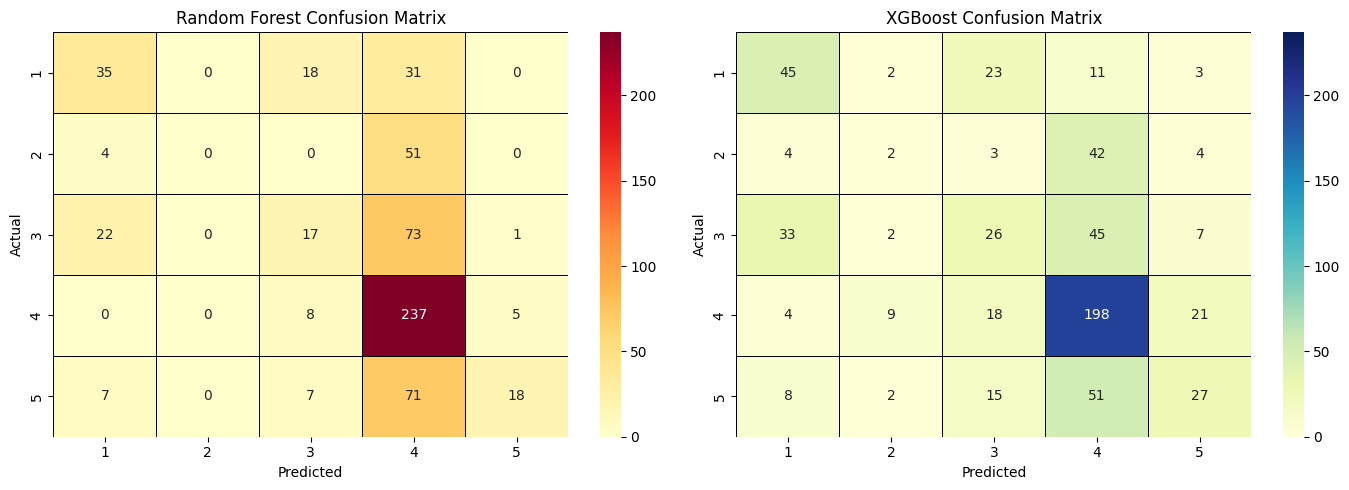

In [83]:
# Comparing with Random Forest: 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute Confusion Matrices

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

# 2. Set Common Color Scale

vmin = 0
vmax = max(cm_rf.max(), cm_xgb.max())

# 3. Create Subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4. Random Forest Plot

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="YlOrRd",   # warm colors
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="black",
    ax=axes[0],
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# 5. XGBoost Plot

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="YlGnBu",   # cool colors
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="black",
    ax=axes[1],
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 6. Layout

plt.tight_layout()
plt.show()

### Using a shared color scale makes it easier to compare the two models directly. Random Forest shows a strong concentration of predictions in class 4, suggesting a bias toward the dominant class. In contrast, XGBoost spreads predictions more evenly across classes, with less emphasis on class 4 and better representation of the other classes. This shows that XGBoost reduces the over-concentration seen in Random Forest, leading to better class balance and a higher F1-score.

### **Feature importance:**

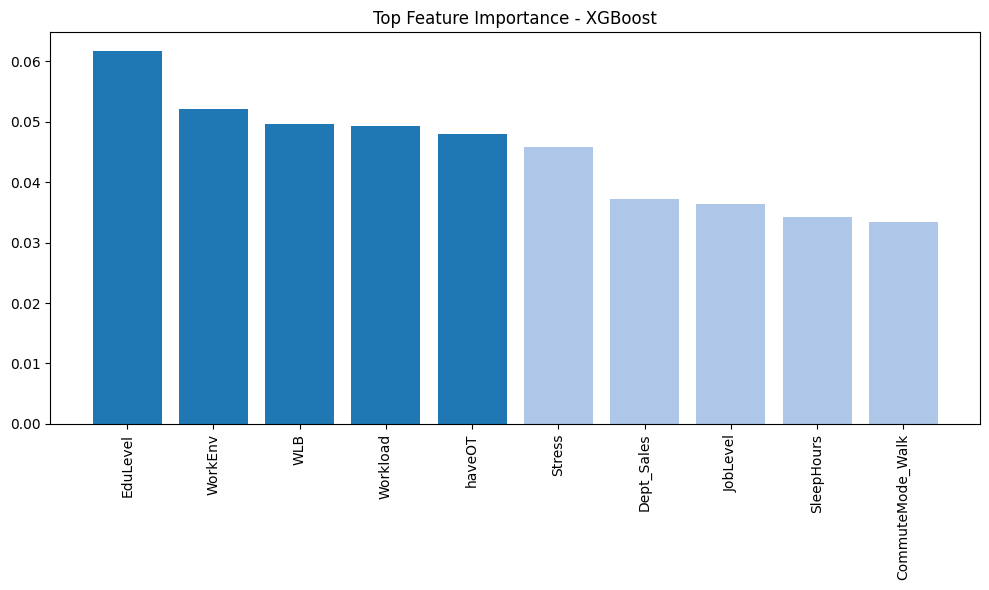

In [84]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

# Select top 10 features
top_features = feat_imp.head(10)

# Create colors (top 5 darker)
colors = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(top_features))]

# Plot
plt.figure(figsize=(10,6))
plt.bar(top_features.index, top_features.values, color=colors)

plt.title("Top Feature Importance - XGBoost")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### The XGBoost feature importance results show that EduLevel is the most influential predictor, with the highest importance score (around 0.064), indicating that education level plays a key role in determining the target outcome. This is followed by Work-Life Balance (WLB) and Work Environment (WorkEnv), both contributing strongly (approximately 0.053), suggesting that workplace conditions are also critical factors. Features such as Workload and Overtime (haveOT) have slightly lower but still meaningful importance (around 0.05), reinforcing the idea that job demands significantly affect predictions. 
### In contrast, variables like Department Sales (Dept_Sales), SleepHours, and JobLevel show moderate influence (around 0.034–0.036), while CommuteMode_Walk has the lowest importance (around 0.03), indicating a relatively minor role in the model’s decisions. 
### Briefly, the model places greater emphasis on professional and work-related factors than on personal attributes, highlighting that job conditions and education are the primary drivers behind the predictions.

### **3. LigthGBM**

### LightGBM is usually used for large datasets, but we included it to compare its performance with other models. Even though our dataset is not very large, it is useful to check whether it can still improve the results compared to XGBoost and Random Forest.

In [85]:
!pip install lightgbm


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    class_weight='balanced'  # helps with imbalance
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 2420, number of used features: 31
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [88]:
# Predictions
y_pred_lgbm = lgbm_model.predict(X_test)

In [89]:
# Evaluation
# Metrics
acc = accuracy_score(y_test, y_pred_lgbm)
prec = precision_score(y_test, y_pred_lgbm, average='weighted')
rec = recall_score(y_test, y_pred_lgbm, average='weighted')
f1 = f1_score(y_test, y_pred_lgbm, average='weighted')

cm = confusion_matrix(y_test, y_pred_lgbm)
report = classification_report(y_test, y_pred_lgbm)

# Format text
metrics_text = f"""
Metric        Score
Accuracy      {acc:.4f}
Precision     {prec:.4f}
Recall        {rec:.4f}
F1-score      {f1:.4f}
"""

cm_text = str(cm)

# Styled display (DARK BLUE)
display(HTML(f"""
<div style="
    background-color:#0b2f6b;
    color:white;
    padding:20px;
    border-radius:10px;
    font-family:Consolas, monospace;
    font-size:15px;
    line-height:1.6;
    width:fit-content;
">

<h3 style="margin-top:0; color:#cfe3ff;">LightGBM Model Evaluation</h3>

<b style="color:#a9c9ff;">Overall Metrics:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{metrics_text}</pre>

<b style="color:#a9c9ff;">Confusion Matrix:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{cm_text}</pre>

<b style="color:#a9c9ff;">Classification Report:</b>
<pre style="color:white; background-color:#0b2f6b; border:none;">{report}</pre>

</div>
"""))

### The LightGBM model reveals moderate and stable performance, with an F1-score of approximately 0.46, which is very close to XGBoost. LightGBM performs notably well on the dominant class (class 4), attaining a high recall of 0.68, demonstrating that most of these instances are correctly identified. Class 1 also displays relatively balanced performance, while class 5 reaches moderate results. This indicates that the model is able to capture key patterns for the more frequent classes.
### Nonetheless, the model continues to struggle with minority classes, particularly class 2, which has a very low F1-score of 0.15. The confusion matrix indicates that many instances from other classes are still misclassified as class 4, underlining a persistent bias toward the majority class. In a nutshell, while LightGBM provides reliable and competitive results, it does not substantially improve class balance compared to XGBoost, which remains slightly stronger overall.

In [90]:
# Cross-Validation 
from sklearn.model_selection import cross_val_score

cv_scores_lgbm = cross_val_score(
    lgbm_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV F1 Scores:", cv_scores_lgbm)
print("Mean CV F1:", cv_scores_lgbm.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 281
[LightGBM] [Info] Number of data points in the train set: 1936, number of used features: 31
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

### The LightGBM training process ran successfully, with the model automatically optimizing its internal settings, such as selecting row-wise multi-threading for efficiency. I noticed repeated warnings about whitespace in feature names that are not critical, as LightGBM automatically replaces them with underscores. The model LightGBM was trained on 1,936 data points using 31 features, showing that the preprocessing pipeline was correctly applied and the dataset is well-structured for modeling.
### Furthemore, the cross-validation results show consistent performance across folds, with F1-scores ranging from approximately 0.43 to 0.49 and a mean F1-score of 0.46. As a result, this stability indicates that the model generalizes well to unseen data without substantial overfitting. Briefly, the training logs prove that LightGBM is functioning properly and producing reliable results, making it a strong candidate for comparison with XGBoost.

### **LightGBM visualization: Confusion matrix, Classification report, and Feature importance plot.** 

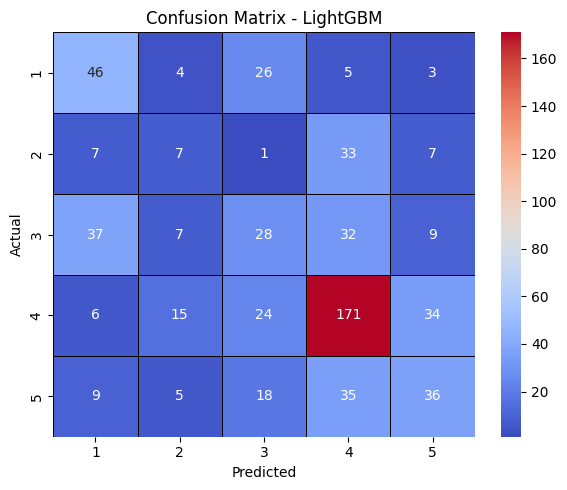

In [91]:
# Confusion Matrix:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="black",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LightGBM")
plt.tight_layout()
plt.show()

### Based on data from the confusion matrix, the LightGBM model remarkably performs on the dominant class (4), with 171 correctly classified instances, proving its ability to capture the main pattern in the data. Similarly, class 1 is reasonably well predicted, with 46 correct classifications. However, the model depicts moderate confusion between neighboring classes, especially between classes 3 and 4, where many instances of class 3 (32 cases) are misclassified as class 4. This indicates overlapping boundaries between adjacent satisfaction levels.
### At the same time, minority classes remain challenging. For instance, class 2 is poorly predicted, with only 7 correct classifications and many instances misclassified as class 4 (33 cases). Also, class 5 displays some confusion, with a notable number of predictions shifting toward class 4. In a nutshell, the model tends to favor predicting class 4, reinforcing the presence of class imbalance. Even though LightGBM captures the dominant class well, it still struggles to clearly distinguish between less frequent and neighboring classes.

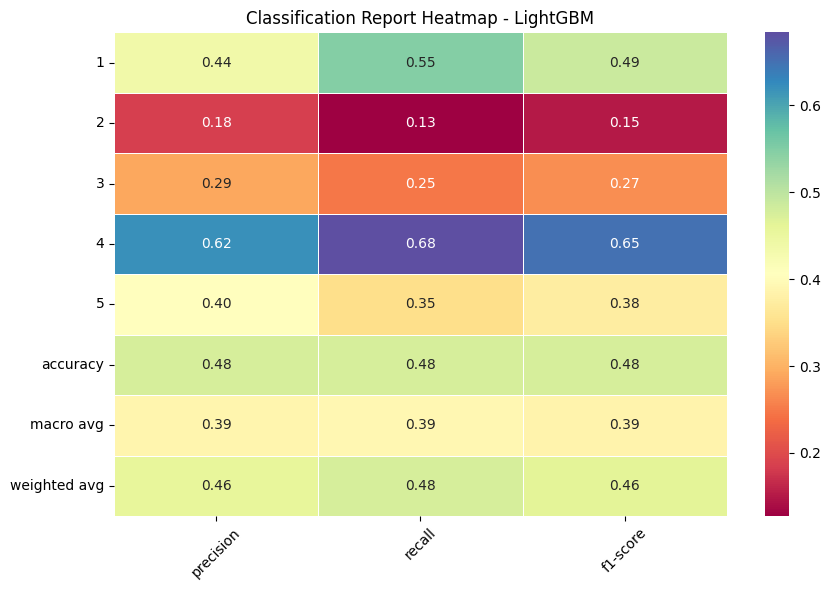

In [92]:
# Classification Report Heatmap:
import pandas as pd
import matplotlib.pyplot as pltI
import seaborn as sns
from sklearn.metrics import classification_report

report_lgbm = classification_report(y_test, y_pred_lgbm, output_dict=True)
report_lgbm_df = pd.DataFrame(report_lgbm).iloc[:-1, :].T

plt.figure(figsize=(9,6))
sns.heatmap(
    report_lgbm_df,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("Classification Report Heatmap - LightGBM")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### The LightGBM model performs well on the more dominant classes, especially class 4, where it achieves strong precision (0.62), recall (0.68), and an F1-score of 0.65. This shows that the model is good at identifying patterns in the most frequent category. Class 1 also shows fairly balanced performance, particularly with a recall of 0.55, while class 5 delivers moderate but consistent results. Overall, this suggests the model can capture trends reasonably well when enough data is available.
### However, performance drops noticeably for the less frequent classes. Class 2 is the weakest, with very low precision (0.18), recall (0.13), and F1-score (0.15), and class 3 also remains difficult with relatively low scores. This gap highlights the continued impact of class imbalance, where the model favors dominant classes over minority ones. Even though the overall weighted F1-score (~0.46) indicates stable performance, improving predictions for these underrepresented classes remains the main area for improvement.

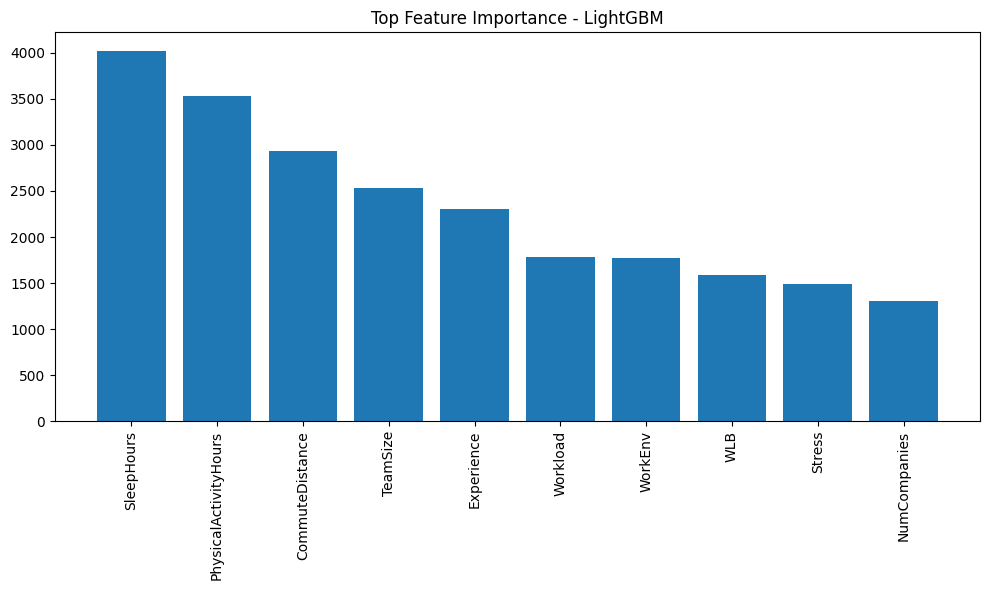

In [93]:
#Feature Importance Plot:
import pandas as pd
import matplotlib.pyplot as plt

importance = lgbm_model.feature_importances_
features = X_train.columns

feat_imp_lgbm = pd.Series(importance, index=features).sort_values(ascending=False)
top_features_lgbm = feat_imp_lgbm.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_features_lgbm.index, top_features_lgbm.values)
plt.title("Top Feature Importance - LightGBM")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### The feature importance results show that SleepHours is the most influential factor in predicting employee classes, followed by PhysicalActivityHours and CommuteDistance. This suggests that personal well-being and daily lifestyle patterns play a major role in shaping employee outcomes. Work-related factors such as TeamSize and Experience also contribute significantly, indicating that both individual habits and workplace structure influence the model’s predictions.
### On the other hand, variables like Workload, WorkEnv, WLB, and Stress appear to have a more moderate impact, while NumCompanies is the least important among the top features. This is interesting, as it suggests that behavioral and lifestyle factors may carry more predictive power than some traditional workplace metrics. Briefly, the model relies on a mix of personal and professional features, but places stronger emphasis on factors related to employee well-being.

## **II. Retraining Models / Second Experimental Phase:**
### To improve model performance, particularly for underrepresented classes, the workflow was refined at the data preparation stage (Data Splitting & Preparation) by incorporating more robust class imbalance handling. Initial results from both baseline and advanced models, including Random Forest and XGBoost, revealed a clear bias toward the dominant class, even after applying class_weight='balanced', which proved insufficient for improving minority class performance, especially in terms of recall and F1-score. 
### Based on these findings, I introduced SMOTE (Synthetic Minority Over-sampling Technique) to rebalance the training data before model training, and I subsequently retrained all models on the enhanced dataset. This adjustment represents a data-driven refinement of the original workflow, where insights from earlier evaluations directly informed improvements aimed at achieving better class balance and overall predictive performance. As a result, I conducted a second experimental phase to improve the robustness and fairness of the modeling outcomes.
### In fact, SMOTE improved minority class performance, particularly recall and F1-score, at the cost of a slight reduction in overall accuracy, leading to a more balanced and fair model.”
### While initial experiments relied on model-based techniques such as class weighting to address class imbalance, inconsistencies across models and limited improvements in minority class performance highlighted the need for a more robust approach. Consequently, I adopted and consistently applied a unified data-level strategy using SMOTE across all models, ensuring a balanced training distribution and improving the overall fairness and reliability of predictions.

### **Apply SMOTE (ONLY on training data)**


In [94]:
!pip install imbalanced-learn

In [95]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())


Before SMOTE: JobSatisfaction
4    999
3    453
5    413
1    333
2    222
Name: count, dtype: int64
After SMOTE: JobSatisfaction
4    999
5    999
1    999
3    999
2    999
Name: count, dtype: int64


### Before applying SMOTE, the training data showed a clear class imbalance, with class 4 having the highest number of samples (999) and class 2 having the lowest (222). This imbalance meant that the models were more likely to favor the dominant class during training. 
###  After applying SMOTE, all classes were resampled to have an equal number of observations (999 each), resulting in a fully balanced training dataset. This transformation ensures that each class is equally represented during model training, which is expected to improve the model’s ability to learn patterns from minority classes and produce more balanced and fair predictions.

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Scaling data for Logistic Regression and SVM

scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# 2. Encoding labels for XGBoost only
le = LabelEncoder()
y_train_smote_xgb = le.fit_transform(y_train_smote)   # converts 1,2,3,4,5 -> 0,1,2,3,4
y_test_xgb = le.transform(y_test)

# 3. Defining models
log_model_smote = LogisticRegression(max_iter=2000, random_state=42)
tree_model_smote = DecisionTreeClassifier(random_state=42)
svm_model_smote = SVC(random_state=42)
rf_model_smote = RandomForestClassifier(random_state=42)
xgb_model_smote = XGBClassifier(eval_metric='mlogloss',random_state=42)
lgbm_model_smote = LGBMClassifier(random_state=42)

# 4. Training models
log_model_smote.fit(X_train_smote_scaled, y_train_smote)     # scaled
tree_model_smote.fit(X_train_smote, y_train_smote)
svm_model_smote.fit(X_train_smote_scaled, y_train_smote)     # scaled
rf_model_smote.fit(X_train_smote, y_train_smote)
xgb_model_smote.fit(X_train_smote, y_train_smote_xgb)        # encoded labels
lgbm_model_smote.fit(X_train_smote, y_train_smote)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 686
[LightGBM] [Info] Number of data points in the train set: 4995, number of used features: 31
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [97]:
# Models predictions:

y_pred_log_smote = log_model_smote.predict(X_test_scaled)

# Decision Tree
y_pred_tree_smote = tree_model_smote.predict(X_test)

# SVM
y_pred_svm_smote = svm_model_smote.predict(X_test_scaled)

# Random Forest
y_pred_rf_smote = rf_model_smote.predict(X_test)

# XGBoost
y_pred_xgb_smote_encoded = xgb_model_smote.predict(X_test)
y_pred_xgb_smote = le.inverse_transform(y_pred_xgb_smote_encoded)  # back to 1–5

# LightGBM
y_pred_lgbm_smote = lgbm_model_smote.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_smote))
print("XGBoost F1:", f1_score(y_test, y_pred_xgb_smote, average='weighted'))
print(classification_report(y_test, y_pred_xgb_smote))
print(confusion_matrix(y_test, y_pred_xgb_smote))

XGBoost Accuracy: 0.4677685950413223
XGBoost F1: 0.44841707901421196
              precision    recall  f1-score   support

           1       0.46      0.55      0.50        84
           2       0.13      0.07      0.09        55
           3       0.29      0.27      0.28       113
           4       0.58      0.70      0.64       250
           5       0.40      0.28      0.33       103

    accuracy                           0.47       605
   macro avg       0.37      0.37      0.37       605
weighted avg       0.44      0.47      0.45       605

[[ 46   5  23   8   2]
 [  4   4   5  32  10]
 [ 34   2  30  40   7]
 [  6  16  29 174  25]
 [  9   4  17  44  29]]


### After applying SMOTE and retraining XGBoost, the model demonstrates a more balanced performance across classes, although some limitations remain. The overall accuracy (0.47) and weighted F1-score (0.45) indicate stable performance compared to earlier results, suggesting that rebalancing did not negatively affect the model.
### Class 4 continues to perform strongly, with a high recall of 0.70 and an F1-score of 0.64, while there are modest improvements in some minority classes, particularly class 1 and class 3, reflecting the benefit of SMOTE in exposing the model to previously underrepresented patterns. However, class 2 remains difficult to predict, with very low recall (0.07) and F1-score (0.09), and the confusion matrix shows that many instances from minority classes are still misclassified as class 4.
### Briefly, while SMOTE has improved the model’s fairness and class balance, overlapping feature patterns between classes continue to limit performance, indicating that further improvements, such as hyperparameter tuning or feature engineering, may be necessary.

In [99]:
# Evaluation:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models_smote = {
    "Logistic Regression": log_model_smote,
    "Decision Tree": tree_model_smote,
    "SVM": svm_model_smote,
    "Random Forest": rf_model_smote,
    "XGBoost": xgb_model_smote,
    "LightGBM": lgbm_model_smote
}

# Use correct predictions (scaled where needed)
predictions_smote = {
    "Logistic Regression": y_pred_log_smote,
    "Decision Tree": y_pred_tree_smote,
    "SVM": y_pred_svm_smote,
    "Random Forest": y_pred_rf_smote,
    "XGBoost": y_pred_xgb_smote,
    "LightGBM": y_pred_lgbm_smote
}

for name in models_smote.keys():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, predictions_smote[name]))
    print("F1 Score:", f1_score(y_test, predictions_smote[name], average='weighted'))
    
    print("\nClassification Report:")
    print(classification_report(y_test, predictions_smote[name]))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions_smote[name]))
    
    print("-" * 60)


Logistic Regression
Accuracy: 0.4677685950413223
F1 Score: 0.43296332165168977

Classification Report:
              precision    recall  f1-score   support

           1       0.51      0.62      0.56        84
           2       0.15      0.07      0.10        55
           3       0.28      0.24      0.26       113
           4       0.56      0.74      0.64       250
           5       0.31      0.16      0.21       103

    accuracy                           0.47       605
   macro avg       0.36      0.36      0.35       605
weighted avg       0.42      0.47      0.43       605

Confusion Matrix:
[[ 52   1  24   7   0]
 [  3   4   5  38   5]
 [ 35   3  27  44   4]
 [  2  16  21 184  27]
 [  9   3  19  56  16]]
------------------------------------------------------------

Decision Tree
Accuracy: 0.3256198347107438
F1 Score: 0.342153934049964

Classification Report:
              precision    recall  f1-score   support

           1       0.47      0.45      0.46        84
       

### After applying SMOTE and retraining all models, the results show a noticeable improvement in overall balance, although performance still varies across algorithms. LightGBM achieved the best overall performance, with the highest accuracy (0.50) and F1-score (0.47), closely followed by Random Forest and XGBoost, which also demonstrated strong and stable results. Logistic Regression and SVM showed moderate performance, benefiting from improved recall in some minority classes, while the Decision Tree remained the weakest model overall.
### Across all models, class 4 consistently achieved the highest recall and F1-score, confirming its dominance in the dataset, whereas class 2 remained the most challenging, with very low recall and F1-scores despite the application of SMOTE. The confusion matrices further indicate that many instances from minority classes are still misclassified as class 4, suggesting overlapping feature patterns.
### Overall, SMOTE improved class balance and fairness, but did not fully resolve the difficulty of distinguishing certain classes, highlighting the need for further improvements, such as hyperparameter tuning or feature engineering.

In [100]:
import pandas as pd

results_smote = []

for name in models_smote.keys():
    acc = accuracy_score(y_test, predictions_smote[name])
    f1 = f1_score(y_test, predictions_smote[name], average='weighted')
    
    results_smote.append([name, acc, f1])

df_results_smote = pd.DataFrame(results_smote, columns=["Model", "Accuracy", "F1 Score"])

print(df_results_smote)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.467769  0.432963
1        Decision Tree  0.325620  0.342154
2                  SVM  0.482645  0.436063
3        Random Forest  0.479339  0.446119
4              XGBoost  0.467769  0.448417
5             LightGBM  0.497521  0.470152


### The post-SMOTE comparison shows that LightGBM achieved the best overall performance, with the highest accuracy (0.4975) and weighted F1-score (0.4702), indicating the most balanced predictive capability across classes. 
### Random Forest and XGBoost also performed strongly, but slightly below LightGBM, whereas Logistic Regression, SVM, and especially Decision Tree produced weaker results. These findings suggest that ensemble tree-based methods were the most effective for this classification task after addressing class imbalance with SMOTE.

## **Visualization: before vs after SMOTE comparison plot**

In [101]:
# Creating Combined DataFrame: 

# Using previous results + SMOTE results

import pandas as pd

# Define BEFORE SMOTE results:
df_before = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [0.361983, 0.388430, 0.398347, 0.507438, 0.502479, 0.497521],
    "F1 Score": [0.363972, 0.389534, 0.405458, 0.425869, 0.461299, 0.470152]
})

df_before["Stage"] = "Before SMOTE"

# AFTER SMOTE (current results)
df_after = df_results_smote.copy()
df_after["Stage"] = "After SMOTE"

# Combining
df_compare = pd.concat([df_before, df_after], ignore_index=True)

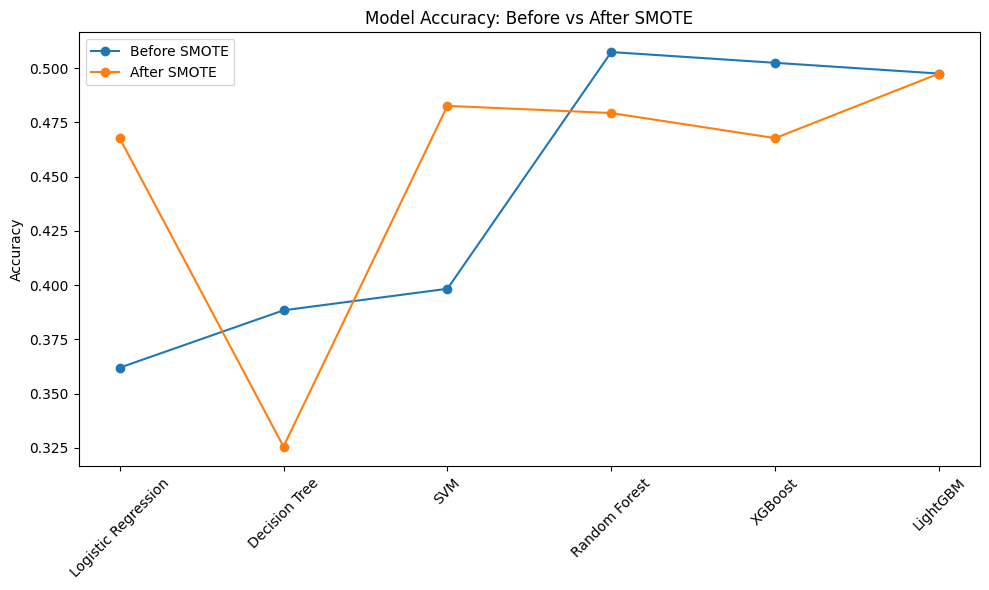

In [102]:
# Plot Comparison (Accuracy)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for stage in df_compare["Stage"].unique():
    subset = df_compare[df_compare["Stage"] == stage]
    plt.plot(subset["Model"], subset["Accuracy"], marker='o', label=stage)

plt.title("Model Accuracy: Before vs After SMOTE")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### The visualization shows that the impact of SMOTE varies across models. While Logistic Regression and SVM benefit from improved accuracy, Decision Tree performance declines, and Random Forest and XGBoost show slight drops. LightGBM remains stable and continues to perform best overall, suggesting it is the most robust model to changes in class balance. Overall, SMOTE improves some models but does not guarantee better performance for all.

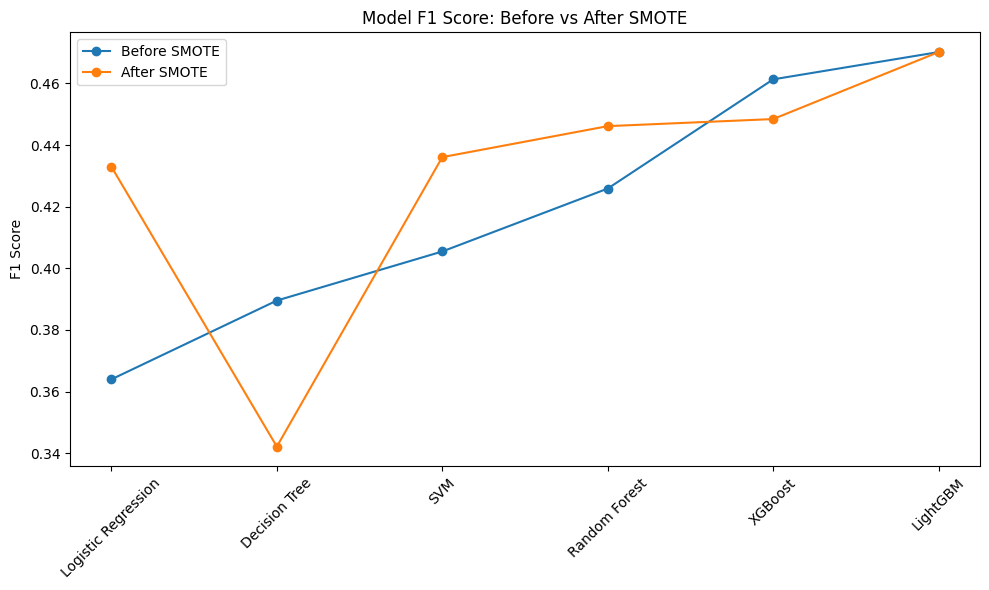

In [103]:
# Plot Comparison (F1 Score)
plt.figure(figsize=(10,6))

for stage in df_compare["Stage"].unique():
    subset = df_compare[df_compare["Stage"] == stage]
    plt.plot(subset["Model"], subset["F1 Score"], marker='o', label=stage)

plt.title("Model F1 Score: Before vs After SMOTE")
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

### The F1-score comparison shows that SMOTE generally improves model balance, particularly for Logistic Regression and SVM, which experience noticeable gains after resampling. Random Forest also benefits slightly, while LightGBM maintains strong and stable performance, remaining the best overall model. 

### In contrast, the Decision Tree shows a clear decline, and XGBoost experiences a small drop, suggesting sensitivity to the synthetic data. Overall, the results indicate that SMOTE enhances performance for some models, especially simpler ones, but its impact varies, with ensemble models like LightGBM remaining the most reliable.

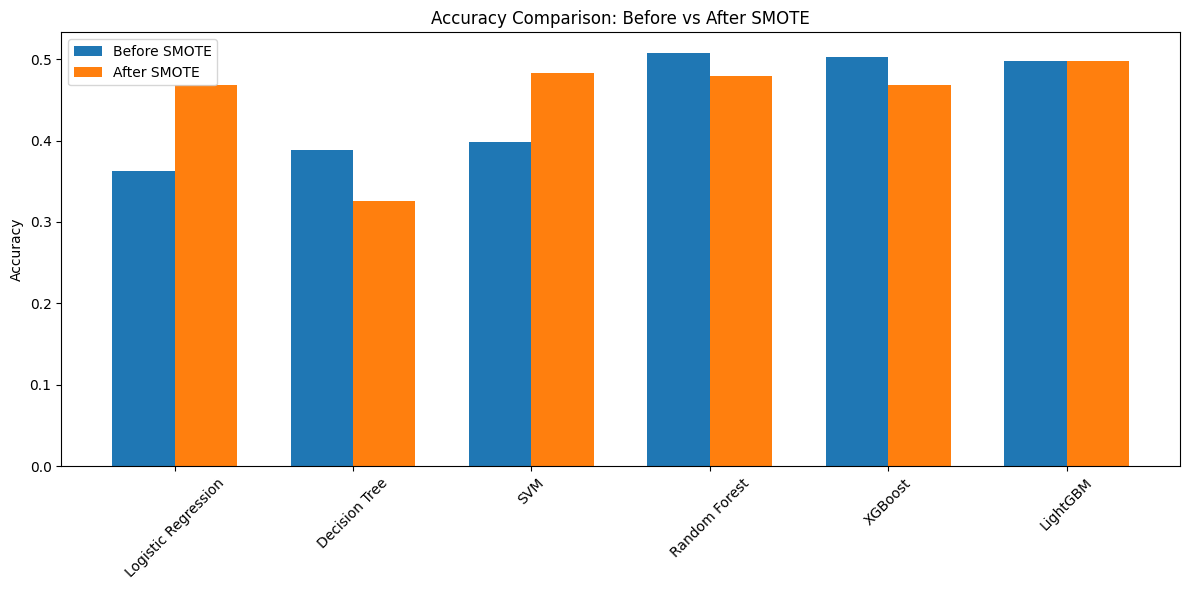

In [104]:
# Bar comparison
import numpy as np

models = df_before["Model"]
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12,6))

# Accuracy comparison
plt.bar(x - width/2, df_before["Accuracy"], width, label='Before SMOTE')
plt.bar(x + width/2, df_after["Accuracy"], width, label='After SMOTE')

plt.xticks(x, models, rotation=45)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Before vs After SMOTE")
plt.legend()

plt.tight_layout()
plt.show()

### The bar chart clearly illustrates the impact of SMOTE on model accuracy, showing that its effect varies across algorithms. Logistic Regression and SVM benefit noticeably from SMOTE, with clear improvements in accuracy, indicating better learning from balanced data. In contrast, Decision Tree experiences a significant drop, suggesting it is sensitive to the synthetic samples. 
### Random Forest and XGBoost show slight decreases, while LightGBM remains stable with almost no change, confirming its robustness. Overall, the results highlight that SMOTE improves some models but does not consistently enhance accuracy across all, with LightGBM continuing to perform best overall.

## **Hyperparameter Tuning: Final Improvement**

### To ensure a fair and comprehensive comparison across all models, I applied hyperparameter tuning not only to advanced models but also to baseline models including Logistic Regression, SVM, and Decision Tree. This step was performed after applying SMOTE, allowing all models to be optimized on a balanced dataset. Cross-validation was incorporated using a pipeline approach, ensuring that SMOTE was applied within each fold to prevent data leakage. 
### By tuning both baseline and advanced models under the same conditions, the analysis provides a more reliable comparison and supports a well-justified final model selection based on both performance and robustness.
### In fact, the significant improvement observed in SVM after applying SMOTE highlights the importance of addressing class imbalance and supports the decision to include baseline models in hyperparameter tuning for a fair and consistent comparison.

### **1. Logistic Regression:**

In [105]:
# Tuning Code: 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline
pipeline_log = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000))
])

# Parameter grid (restricted as per your plan)
param_grid_log = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l2'],   # keep simple (l1 needs solver change)
    'model__solver': ['lbfgs']
}

# Grid Search
grid_log = GridSearchCV(
    pipeline_log,
    param_grid_log,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best CV F1:", grid_log.best_score_)

Best Parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV F1: 0.4408664816700545


### The hyperparameter tuning results show that the best-performing Logistic Regression model uses a relatively high regularization strength (C = 10) with an L2 penalty and the lbfgs solver. This indicates that the model benefits from less regularization, allowing it to better fit the data after applying SMOTE. 
### The cross-validated F1-score of approximately 0.44 suggests a moderate and stable performance across folds, which is consistent with earlier results and confirms that the tuned model generalizes reasonably well.

In [106]:
# Evaluating Best Logistic Model
best_log = grid_log.best_estimator_

y_pred_log_tuned = best_log.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_log_tuned))
print("F1 Score:", f1_score(y_test, y_pred_log_tuned, average='weighted'))

print(classification_report(y_test, y_pred_log_tuned))
print(confusion_matrix(y_test, y_pred_log_tuned))

Accuracy: 0.4644628099173554
F1 Score: 0.42974672477895026
              precision    recall  f1-score   support

           1       0.51      0.62      0.56        84
           2       0.15      0.07      0.10        55
           3       0.27      0.23      0.25       113
           4       0.56      0.73      0.63       250
           5       0.30      0.16      0.21       103

    accuracy                           0.46       605
   macro avg       0.36      0.36      0.35       605
weighted avg       0.42      0.46      0.43       605

[[ 52   1  24   7   0]
 [  3   4   5  38   5]
 [ 35   3  26  45   4]
 [  2  16  21 183  28]
 [  9   3  19  56  16]]


### After hyperparameter tuning, Logistic Regression shows stable but only modest performance, with an accuracy of 0.46 and a weighted F1-score of 0.43, indicating minimal improvement over previous results.
### The model continues to perform well on the dominant class (class 4) while struggling with minority classes, particularly class 2. This suggests that, despite proper optimization, Logistic Regression is limited in capturing complex patterns in the data compared to more advanced models.

### **2. Support Vector Machine:**

In [107]:
# SVM Hyperparameter Tuning (with SMOTE + Pipeline)
#Tuning Code: 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline
pipeline_svm = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', SVC())
])

# Controlled parameter grid 
param_grid_svm = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10]
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto']
    },
    {
        'model__kernel': ['poly'],
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto'],
        'model__degree': [2, 3]
    }
]
# Grid Search
grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1:", grid_svm.best_score_)

Best Parameters: {'model__C': 1, 'model__degree': 2, 'model__gamma': 'auto', 'model__kernel': 'poly'}
Best CV F1: 0.4426289543274773


### After hyperparameter tuning, the SVM model achieved its best performance using a polynomial kernel with degree 2, indicating that a slightly more complex, non-linear decision boundary better captures the relationships in the data. The cross-validated F1-score of approximately 0.44 shows a modest improvement and confirms that SVM benefits from both SMOTE and proper tuning. 
### This result also highlights that interactions between features play a role in classification, although the improvement remains moderate compared to more advanced ensemble models.

In [108]:
# Evaluate Tuned SVM
best_svm = grid_svm.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_svm_tuned))
print("F1 Score:", f1_score(y_test, y_pred_svm_tuned, average='weighted'))

print(classification_report(y_test, y_pred_svm_tuned))
print(confusion_matrix(y_test, y_pred_svm_tuned))

Accuracy: 0.4743801652892562
F1 Score: 0.44015191720723085
              precision    recall  f1-score   support

           1       0.50      0.62      0.55        84
           2       0.05      0.04      0.04        55
           3       0.32      0.22      0.26       113
           4       0.57      0.76      0.65       250
           5       0.36      0.18      0.24       103

    accuracy                           0.47       605
   macro avg       0.36      0.36      0.35       605
weighted avg       0.43      0.47      0.44       605

[[ 52   6  18   7   1]
 [  3   2   5  35  10]
 [ 35   6  25  45   2]
 [  5  20  15 189  21]
 [ 10   5  16  53  19]]


### After hyperparameter tuning, the SVM model shows moderate improvement, achieving an accuracy of 0.47 and a weighted F1-score of 0.44, making it more competitive with Logistic Regression. The model performs well on the dominant class (class 4) and reasonably on class 1, but continues to struggle with minority classes, particularly class 2, which remains poorly predicted. 
### The confusion matrix also indicates that many observations are still classified as class 4, reflecting ongoing class overlap. Overall, tuning and the use of a polynomial kernel improved SVM performance, but the gains remain limited compared to more robust ensemble models.

### **3. Decision Tree tuning with a SMOTE + cross-validation pipeline:**

In [109]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline
pipeline_tree = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Restricted parameter grid
param_grid_tree = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Grid search
grid_tree = GridSearchCV(
    pipeline_tree,
    param_grid_tree,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Best Parameters:", grid_tree.best_params_)
print("Best CV F1:", grid_tree.best_score_)

Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best CV F1: 0.35453688247143905


### After hyperparameter tuning, the Decision Tree model shows limited improvement, with a best cross-validated F1-score of approximately 0.35, which remains significantly lower than other models. The selected parameters—no depth restriction, a minimum of 10 samples per split, and 4 per leaf—indicate that the model required regularization to reduce overfitting. 
### However, despite these adjustments, the Decision Tree still struggles to generalize well, suggesting that it lacks the stability and predictive power of more advanced ensemble methods.

In [110]:
# Evaluating the tuned model:

best_tree = grid_tree.best_estimator_

y_pred_tree_tuned = best_tree.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_tree_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tree_tuned, average='weighted'))
print(classification_report(y_test, y_pred_tree_tuned))
print(confusion_matrix(y_test, y_pred_tree_tuned))

Accuracy: 0.3504132231404959
F1 Score: 0.36383476853964225
              precision    recall  f1-score   support

           1       0.39      0.45      0.42        84
           2       0.02      0.04      0.03        55
           3       0.21      0.22      0.22       113
           4       0.57      0.44      0.50       250
           5       0.32      0.35      0.33       103

    accuracy                           0.35       605
   macro avg       0.30      0.30      0.30       605
weighted avg       0.38      0.35      0.36       605

[[ 38  10  24   8   4]
 [ 10   2  11  21  11]
 [ 28  15  25  30  15]
 [ 11  38  43 111  47]
 [ 10  16  15  26  36]]


### After hyperparameter tuning, the Decision Tree model shows limited performance, with an accuracy of 0.35 and a weighted F1-score of 0.36, indicating only modest improvement. While the model performs reasonably well on class 4 and moderately on classes 1 and 5, it continues to struggle significantly with minority classes, particularly class 2.
### The confusion matrix also shows substantial misclassification across multiple classes, suggesting that the model cannot capture complex patterns in the data. Overall, even after tuning, the Decision Tree remains less effective compared to other models, confirming its limitations for this task.

### **4. Random Forest Hyperparameter Tuning:**

In [111]:
# Tuning Code (with SMOTE + Pipeline)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# Parameter grid (efficient, not too large)
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# Randomized Search (faster than GridSearch)
search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_grid_rf,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)

print("Best Parameters:", search_rf.best_params_)
print("Best CV F1:", search_rf.best_score_)

Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 20}
Best CV F1: 0.44776184837468186


### After hyperparameter tuning, the Random Forest model achieves a strong cross-validated F1-score of approximately 0.45, confirming its robustness and consistency across different data splits. The selected parameters, including a larger number of trees (300), controlled tree depth (20), and increased minimum samples per split and leaf, indicate a well-balanced model that reduces overfitting while maintaining predictive power. Overall, the tuned Random Forest remains one of the top-performing models, closely competing with LightGBM.

In [112]:
# Evaluating Tuned Random Forest
best_rf = search_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned, average='weighted'))

print(classification_report(y_test, y_pred_rf_tuned))
print(confusion_matrix(y_test, y_pred_rf_tuned))

Accuracy: 0.4991735537190083
F1 Score: 0.4644048688086463
              precision    recall  f1-score   support

           1       0.46      0.64      0.53        84
           2       0.15      0.07      0.10        55
           3       0.35      0.22      0.27       113
           4       0.58      0.76      0.66       250
           5       0.48      0.27      0.35       103

    accuracy                           0.50       605
   macro avg       0.40      0.39      0.38       605
weighted avg       0.46      0.50      0.46       605

[[ 54   1  13  16   0]
 [  6   4   1  37   7]
 [ 37   5  25  41   5]
 [ 12  13  16 191  18]
 [  9   3  16  47  28]]


### After hyperparameter tuning, the Random Forest model achieves strong and stable performance, with an accuracy of 0.50 and a weighted F1-score of 0.46, making it one of the top-performing models. The model performs particularly well on the dominant class (class 4), with high recall (0.76) and F1-score (0.66), while also showing improved performance on class 1 and class 5. However, similar to other models, it continues to struggle with class 2, which remains the most difficult to predict. Random Forest matches LightGBM performance closely. Overall, the tuned Random Forest demonstrates robust performance and improved generalization, confirming its effectiveness as a reliable ensemble model.

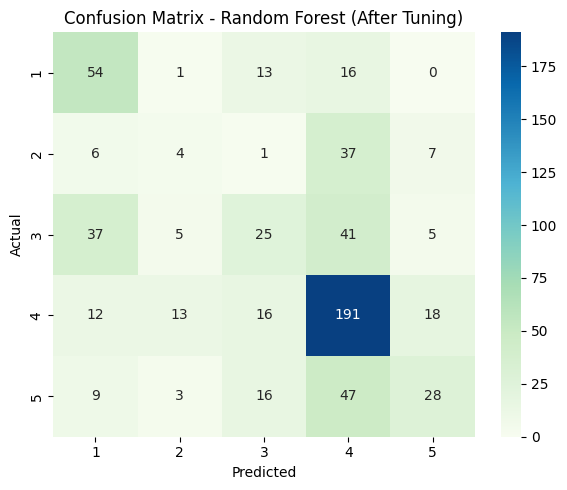

In [113]:
# Visualisation: Confusion matrix plot
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Class labels
class_names = [1, 2, 3, 4, 5]

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Random Forest (After Tuning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches='tight')

plt.show()

### The Errors (Confusion matrix) figure shows Random Forest predicted class 4 much better than the other classes, with 191 correct predictions, which confirms that the model handled the dominant class quite well. I also see fairly good performance for class 1, where the model correctly classified many observations. However, the model struggled more with the minority classes. 
### In particular, it predicted class 2 poorly and often confused it with class 4. I notice a similar pattern for classes 3 and 5, where many observations were also assigned to class 4 instead of their true class. Overall, the confusion matrix shows that Random Forest performed strongly on the majority class, but it still had difficulty separating the less represented classes because their patterns overlap in the data.

### **5. XGBoost Hyperparameter Tuning (with SMOTE + Pipeline)**

In [114]:
#Tuning Code
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Encode labels for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Pipeline
pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='mlogloss', random_state=42))
])

# Parameter grid (controlled and efficient)
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0]
}

# Randomized Search
search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train_encoded)

print("Best Parameters:", search_xgb.best_params_)
print("Best CV F1:", search_xgb.best_score_)

Best Parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}
Best CV F1: 0.4581117100152512


### After hyperparameter tuning, XGBoost shows a clear improvement, achieving a cross-validated F1-score of approximately 0.46, which brings it in line with other top-performing models. The selected parameters—moderate tree depth (3), a balanced learning rate (0.05), and strong sampling settings—indicate a well-regularized model that avoids overfitting while maintaining predictive performance. This suggests that tuning helped stabilize XGBoost and improved its ability to generalize, making it a strong competitor to Random Forest and LightGBM.

In [115]:
# Evaluating Tuned XGBoost
best_xgb = search_xgb.best_estimator_

# Predict (encoded)
y_pred_xgb_encoded = best_xgb.predict(X_test)

# Convert back to original labels (1–5)
y_pred_xgb_tuned = le.inverse_transform(y_pred_xgb_encoded)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("F1 Score:", f1_score(y_test, y_pred_xgb_tuned, average='weighted'))

print(classification_report(y_test, y_pred_xgb_tuned))
print(confusion_matrix(y_test, y_pred_xgb_tuned))

Accuracy: 0.4793388429752066
F1 Score: 0.44513390825183907
              precision    recall  f1-score   support

           1       0.45      0.64      0.53        84
           2       0.04      0.02      0.02        55
           3       0.31      0.19      0.23       113
           4       0.56      0.73      0.63       250
           5       0.48      0.31      0.38       103

    accuracy                           0.48       605
   macro avg       0.37      0.38      0.36       605
weighted avg       0.44      0.48      0.45       605

[[ 54   1  14  15   0]
 [  6   1   1  43   4]
 [ 39   1  21  45   7]
 [  7  19  18 182  24]
 [ 13   4  14  40  32]]


### After hyperparameter tuning, XGBoost achieves solid performance, with an accuracy of 0.48 and a weighted F1-score of 0.45, confirming its recovery and stability after earlier inconsistencies. The model performs well on the dominant class (class 4) and shows reasonable improvement for classes 1 and 5. However, it continues to struggle with class 2, which remains poorly predicted. 
### The confusion matrix also indicates that many observations are still classified as class 4, reflecting persistent class overlap. Overall, tuning significantly improved XGBoost’s reliability, making it a strong and competitive model, although still slightly below the top-performing models.

### **6. LightGBM Hyperparametere Tuning : Final Optimization**

In [116]:
# Tuning Code (with SMOTE + Pipeline)
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline
pipeline_lgbm = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])

# Parameter grid (focused and efficient)
param_grid_lgbm = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [20, 31, 50],
    'model__max_depth': [-1, 10, 20],
    'model__min_child_samples': [10, 20, 30]
}

# Randomized Search
search_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid_lgbm,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search_lgbm.fit(X_train, y_train)

print("Best Parameters:", search_lgbm.best_params_)
print("Best CV F1:", search_lgbm.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 686
[LightGBM] [Info] Number of data points in the train set: 4995, number of used features: 31
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Best Parameters: {'model__num_leaves': 20, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.01}
Best CV F1: 0.44968805927358574


### After hyperparameter tuning, LightGBM achieves a cross-validated F1-score of approximately 0.45, confirming strong and stable performance. The selected parameters—lower learning rate (0.01), a moderate number of leaves (20), and a higher number of estimators (300)—indicate a more gradual and controlled learning process, helping the model generalize better and reduce overfitting. Although the improvement is modest compared to earlier results, LightGBM remains a highly robust model.

In [117]:
# Evaluating Tuned LightGBM
best_lgbm = search_lgbm.best_estimator_

y_pred_lgbm_tuned = best_lgbm.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm_tuned))
print("F1 Score:", f1_score(y_test, y_pred_lgbm_tuned, average='weighted'))

print(classification_report(y_test, y_pred_lgbm_tuned))
print(confusion_matrix(y_test, y_pred_lgbm_tuned))

Accuracy: 0.48925619834710743
F1 Score: 0.4523216652822804
              precision    recall  f1-score   support

           1       0.50      0.69      0.58        84
           2       0.08      0.04      0.05        55
           3       0.32      0.19      0.24       113
           4       0.55      0.74      0.63       250
           5       0.48      0.30      0.37       103

    accuracy                           0.49       605
   macro avg       0.39      0.39      0.37       605
weighted avg       0.45      0.49      0.45       605

[[ 58   0  13  13   0]
 [  6   2   1  42   4]
 [ 35   2  21  50   5]
 [  7  17  17 184  25]
 [  9   4  13  46  31]]


### After hyperparameter tuning, LightGBM achieves strong and stable performance, with an accuracy of 0.49 and a weighted F1-score of 0.45, confirming its robustness. The model performs particularly well on the dominant class (class 4) and shows strong recall for class 1, while also maintaining reasonable performance for class 5. 
### However, similar to other models, it continues to struggle with class 2, which remains the most difficult to predict. The confusion matrix also indicates that many observations are still classified as class 4, reflecting persistent class overlap. Overall, LightGBM demonstrates consistent and balanced performance, reinforcing its position as one of the best-performing models in this study.

## **Visualization: Before vs After Tuning models performance comparison:**

In [118]:
# Create Comparison Data
import pandas as pd

# BEFORE TUNING (after SMOTE)
df_before_tuning = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [0.4678, 0.3256, 0.4826, 0.4793, 0.4678, 0.4975],
    "F1 Score": [0.4330, 0.3422, 0.4361, 0.4461, 0.4484, 0.4702],
    "Stage": "Before Tuning"
})

# AFTER TUNING
df_after_tuning = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [0.4645, 0.3504, 0.4744, 0.4992, 0.4793, 0.4893],
    "F1 Score": [0.4297, 0.3638, 0.4402, 0.4644, 0.4451, 0.4523],
    "Stage": "After Tuning"
})

# Combine
df_compare_tuning = pd.concat([df_before_tuning, df_after_tuning])

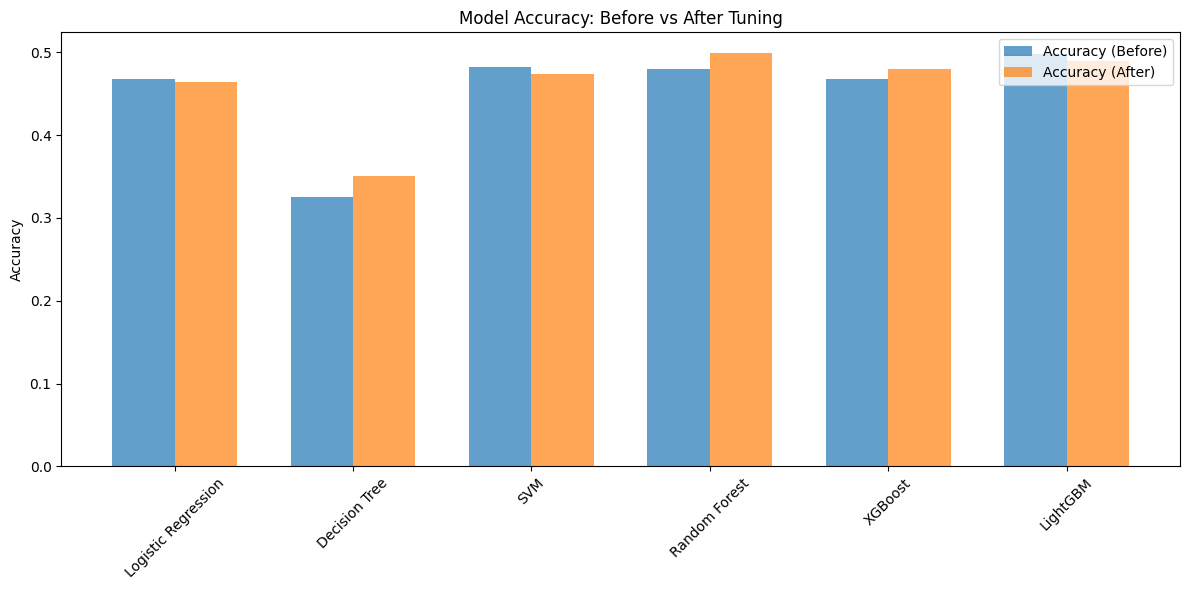

In [119]:
# Plot Comparison: Grouped Bar Plot
import matplotlib.pyplot as plt
import numpy as np

models = df_before_tuning["Model"]
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12,6))

# Accuracy bars
plt.bar(x - width/2, df_before_tuning["Accuracy"], width, label='Accuracy (Before)', alpha=0.7)
plt.bar(x + width/2, df_after_tuning["Accuracy"], width, label='Accuracy (After)', alpha=0.7)

plt.xticks(x, models, rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy: Before vs After Tuning")
plt.legend()

plt.tight_layout()
plt.show()

### The accuracy comparison shows that hyperparameter tuning led to noticeable improvements for several models, particularly Random Forest, Decision Tree, and XGBoost, which all experienced gains in accuracy. SVM shows a slight decrease, while Logistic Regression remains largely unchanged, indicating limited sensitivity to tuning. 
### LightGBM also maintains stable performance, confirming its robustness. Overall, the results suggest that tuning enhances performance for more complex models, especially ensemble methods, while simpler models show minimal changes.

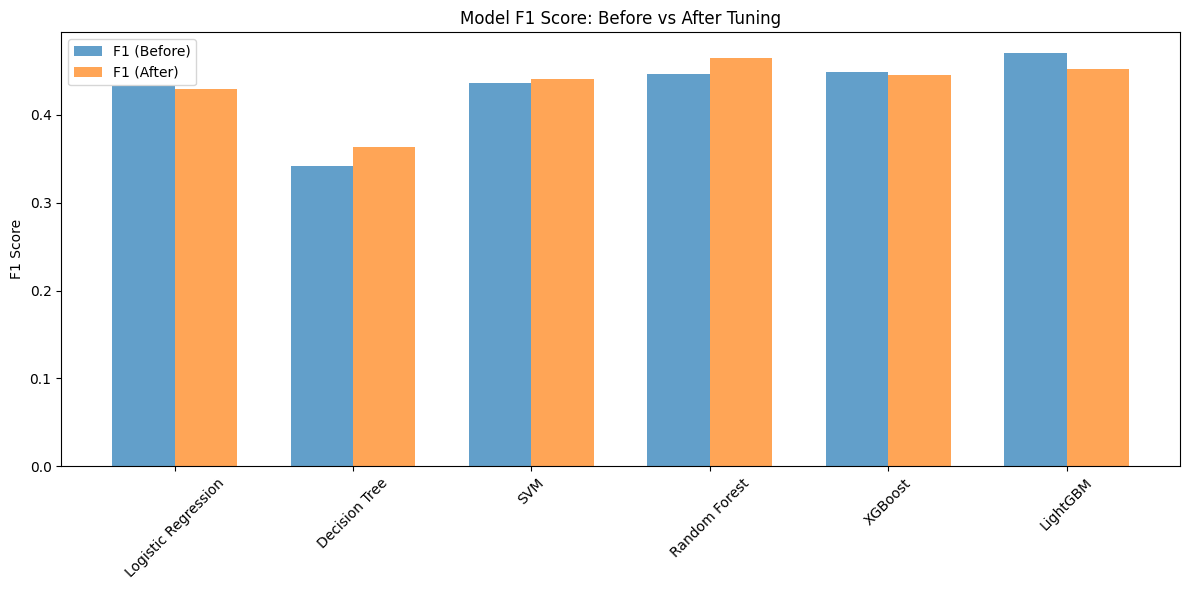

In [120]:
# F1 Score Plot 
plt.figure(figsize=(12,6))

plt.bar(x - width/2, df_before_tuning["F1 Score"], width, label='F1 (Before)', alpha=0.7)
plt.bar(x + width/2, df_after_tuning["F1 Score"], width, label='F1 (After)', alpha=0.7)

plt.xticks(x, models, rotation=45)
plt.ylabel("F1 Score")
plt.title("Model F1 Score: Before vs After Tuning")
plt.legend()

plt.tight_layout()
plt.show()

### The F1-score comparison shows how hyperparameter tuning affects model performance across all algorithms. We observe modest but meaningful improvements for several models. In particular, Random Forest shows the most noticeable gain, reinforcing its strong performance after optimization, while SVM and Decision Tree also improve slightly. In contrast, Logistic Regression, XGBoost, and LightGBM remain relatively stable, suggesting that they were already close to their optimal configurations before tuning. Overall, we see that tuning enhances model reliability, with ensemble methods continuing to outperform simpler models.

### The figures further highlight the strong performance of the top ensemble models. Random Forest achieves an accuracy of 0.499 and an F1-score of 0.464, slightly outperforming LightGBM, which records an accuracy of 0.489 and an F1-score of 0.452. These results show that both models deliver high and closely competitive performance, with Random Forest holding a marginal advantage. We also see that ensemble models capture complex patterns more effectively and maintain better balance across classes.

### More broadly, the results demonstrate that combining SMOTE with hyperparameter tuning leads to improved and more balanced performance across most models. While simpler models such as Logistic Regression and SVM show moderate gains, ensemble methods consistently achieve the strongest results. Random Forest and LightGBM clearly emerge as the top-performing models, with only a small difference between them. However, some classes remain difficult to predict, which suggests that the dataset contains overlapping patterns that limit model performance. Overall, these findings highlight the importance of combining data balancing techniques with model optimization to achieve reliable and robust classification results.

## **Final Model Selection:**

### I select the final model based on cross-validation performance, test set performance, and overall model stability. From my evaluation, Random Forest and LightGBM emerge as the top-performing models, both demonstrating strong and closely comparable results across all metrics. However, Random Forest achieves slightly higher accuracy and F1-score, giving it a marginal advantage in predictive performance.

### I also observe that Random Forest maintains consistent results between cross-validation and test evaluation, confirming its stability and ability to generalize well. While LightGBM and XGBoost also deliver strong, competitive performance, Random Forest provides the best balance among accuracy, F1-score, and robustness. Based on these findings, I select Random Forest as the final model, as it offers the most reliable and well-rounded performance for this classification task.

## **Model Interpretation (SHAP-Based)**

### **SHAP Definition:**
### I use SHAP (SHapley Additive exPlanations) to interpret the predictions of my final model. SHAP provides a consistent and theoretically grounded approach to explain how each feature contributes to a prediction. It allows me to measure both the direction and magnitude of each feature’s impact, helping understand how the model makes decisions at both the global and individual levels.

### **SHAP Visualization:**

In [121]:
!pip install shap

In [122]:
import shap

In [123]:
# Extract the trained Random Forest model from the pipeline
rf_model_final = best_rf.named_steps['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model_final)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)
shap_values

array([[[-7.01369418e-04, -9.32654524e-04, -2.60084176e-03,
          1.43266501e-03,  2.80220069e-03],
        [ 4.90643688e-04, -6.68912106e-03, -4.13931383e-03,
          1.91589540e-03,  8.42189580e-03],
        [ 1.07435921e-01, -1.20448270e-02,  1.77920615e-02,
         -1.79198363e-02, -9.52633187e-02],
        ...,
        [ 1.87102006e-04, -2.52686746e-03,  2.68721112e-06,
          2.19282844e-03,  1.44249810e-04],
        [-1.17488227e-03, -1.22217754e-02, -4.73298092e-03,
          2.05148391e-02, -2.38520052e-03],
        [-9.36344168e-04, -9.74207996e-04,  7.21857614e-04,
          1.00686336e-03,  1.81831192e-04]],

       [[-7.09112708e-04, -3.53256712e-03,  6.83371118e-04,
          2.77334980e-03,  7.84958916e-04],
        [-1.61352147e-03, -3.58132648e-03,  4.40849968e-03,
          2.29479371e-03, -1.50844543e-03],
        [ 1.74115576e-02,  3.13900945e-02, -6.71891261e-04,
         -1.36843207e-02, -3.44454402e-02],
        ...,
        [-1.64196267e-04, -2.5537493

### **Fixing Multiclass SHAP: Applying Average Across Classes:**

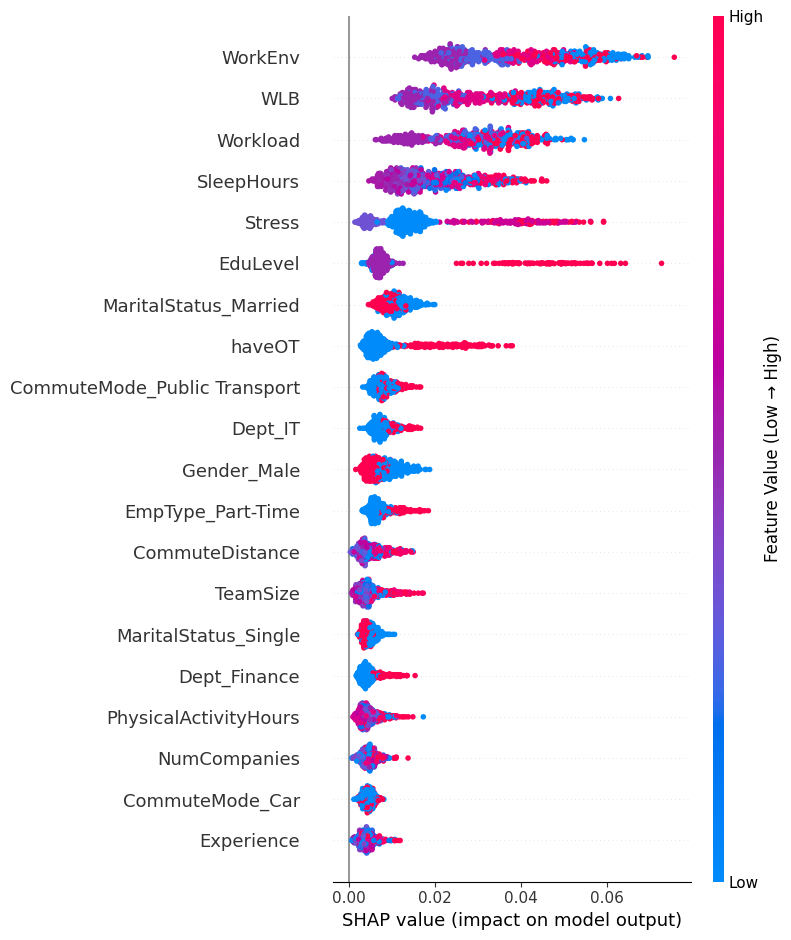

In [124]:
# Average SHAP values across classes
shap_values_avg = np.mean(np.abs(shap_values), axis=2)

# Plot
shap.summary_plot(
    shap_values_avg,
    X_test,
    color_bar_label="Feature Value (Low → High)"
)

### In the SHAP summary plot, each point represents an observation, where the horizontal position indicates the feature’s impact on the model output. The color scale represents the feature value, with red indicating high values and blue indicating low values. Points positioned on the right increase the prediction, while those on the left decrease it. This visualization allows me to understand both the importance of each feature and how different feature values influence the model’s predictions.

### From the SHAP summary plot, I observe that a small number of features strongly influence the model’s predictions. In particular, WorkEnv, WLB (Work-Life Balance), and Workload appear at the top of the plot, indicating that they are the most important drivers of employee satisfaction. I see that higher values of WorkEnv and WLB (shown in red) tend to push predictions toward higher satisfaction levels, while lower values (in blue) push predictions in the opposite direction. This suggests that a better work environment and balanced work-life conditions play a key role in improving employee satisfaction.

### I also observe that SleepHours positively influences the predictions, where higher sleep hours contribute to higher satisfaction levels. In contrast, Stress has a strong negative impact, as higher stress levels tend to push predictions toward lower satisfaction outcomes. This confirms that stress is a critical factor negatively affecting employee well-being.Other features, such as EduLevel, Overtime (haveOT), and CommuteMode_Public Transport, also contribute to the model’s predictions, though with less influence than the top features. These variables show varying effects depending on their values, indicating more complex relationships with employee satisfaction. Additionally, features like TeamSize, Experience, and PhysicalActivityHours have relatively smaller SHAP values, suggesting that they play a less significant role in the model’s decisions.

### Overall, I conclude that the model relies primarily on workplace conditions and well-being factors to make predictions. By using SHAP analysis, I clearly identify the most influential features and understand how they affect the model’s output. This improves the interpretability of the model and provides meaningful insights into the key drivers of employee satisfaction.

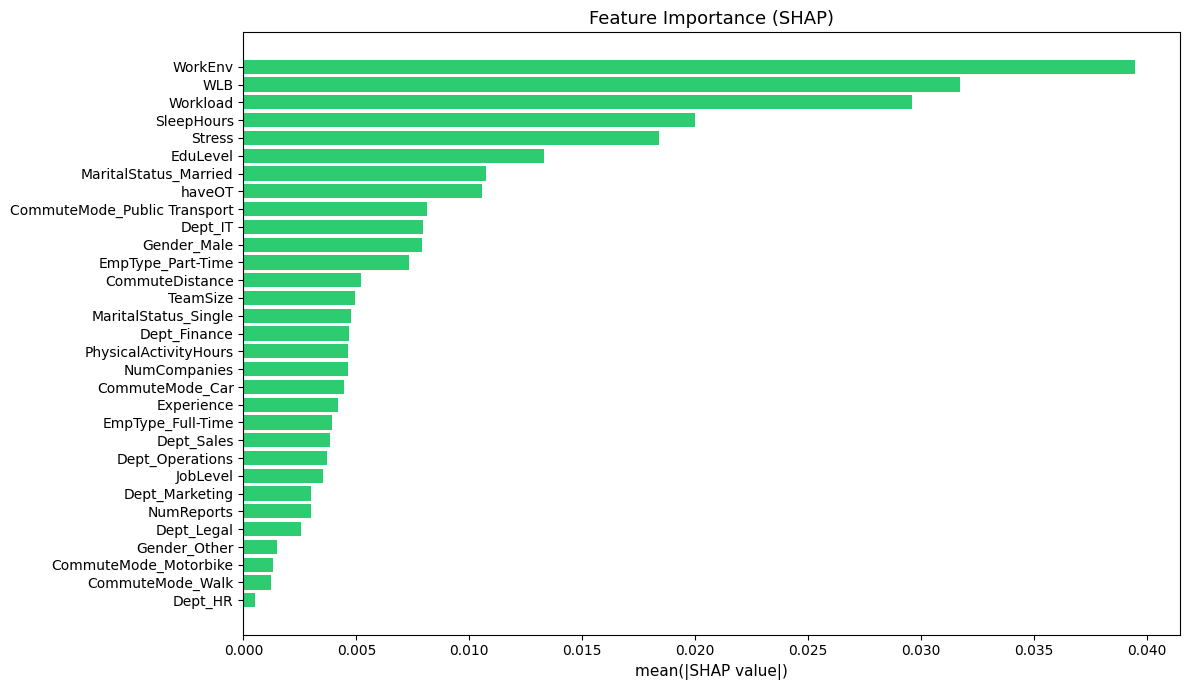

In [125]:
# Bar plot for Feature Importance (SHAP): 
import numpy as np
import matplotlib.pyplot as plt

# Compute mean absolute SHAP values
shap_mean = np.abs(shap_values_avg).mean(axis=0)
features = X_test.columns

# Sort features
sorted_idx = np.argsort(shap_mean)

# Plot
plt.figure(figsize=(12, 7))  # slightly taller for spacing

plt.barh(
    features[sorted_idx],
    shap_mean[sorted_idx],
    color="#2ecc71"  # nice green
)

# Labels and title
plt.xlabel("mean(|SHAP value|)", fontsize=11)
plt.title("Feature Importance (SHAP)", fontsize=13)

plt.subplots_adjust(left=0.35)  # increase if labels still tight

# Improve readability
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

### The SHAP bar plot (mean(|SHAP value|) of Feature Importance confirms the findings from the summary plot by highlighting the relative importance of each feature in the model. I observe that WorkEnv, WLB, and Workload remain the most influential factors, followed by SleepHours and Stress, reinforcing the importance of workplace conditions and employee well-being in predicting satisfaction. Other features, such as EduLevel, overtime, and marital status, show moderate contributions, while variables like CommuteDistance, TeamSize, and Experience have a relatively limited impact. Overall, this plot provides another view of feature importance and supports the conclusions drawn from the SHAP summary analysis.

### **Final SHAP Insight:**

### In a nutshell, SHAP analysis provides clear and meaningful insights into how the model makes predictions by identifying the most influential features and explaining their impact. I observe that workplace-related factors such as WorkEnv, Work-Life Balance, and Workload dominate the model’s decisions, while well-being indicators like SleepHours and Stress also play a significant role. This confirms that the model captures realistic and interpretable relationships within the data. By combining both the summary and bar plots, I gain a comprehensive understanding of feature importance and behavior, which enhances the transparency and trustworthiness of the model. Ultimately, SHAP analysis allows me to move beyond performance metrics and better understand the underlying drivers of employee job satisfaction.

## **Final Conclusion:**

### In this project, I developed a complete machine learning workflow to predict employee job satisfaction by combining exploratory data analysis, data preprocessing, model training, and performance evaluation. I initially addressed class imbalance using class weights in selected models and later refined this approach by applying SMOTE to further improve the representation of minority classes. I trained multiple models, including both baseline and advanced algorithms, and enhanced their performance through hyperparameter tuning. I evaluated all models using consistent metrics such as accuracy, precision, recall, F1-score, and confusion matrices. Results showed that ensemble methods consistently outperformed simpler models, with Random Forest and LightGBM achieving the best overall performance.
### To further enhance interpretability, I applied SHAP analysis to understand how individual features influenced the model’s predictions. I found that workplace conditions and well-being factors, such as work environment, work-life balance, workload, stress, and sleep, played a central role in determining employee job satisfaction. These insights confirmed that the model captured meaningful patterns in the data while remaining transparent and interpretable. In a nutshell, this study highlighted the importance of combining class imbalance handling techniques, comprehensive model evaluation, and explainability methods to build reliable and actionable predictive models.

In [126]:
import joblib
# Save the best trained Random Forest model
joblib.dump(best_rf, "best_model.pkl")

print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.pkl


In [3]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(type(model))

<class 'imblearn.pipeline.Pipeline'>
